## Import all the necessary config files

In [1]:
#is python selected as the kernel?
#have you closed the parameters excel sheet?

from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)

#if you get an error here you propoably didn't close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'C2_2 Ge sedi event sp unknown 27112025' #if this name is too long wont run 

## Run the coral model

## Run simulation for n number of times and plot the total coral cover

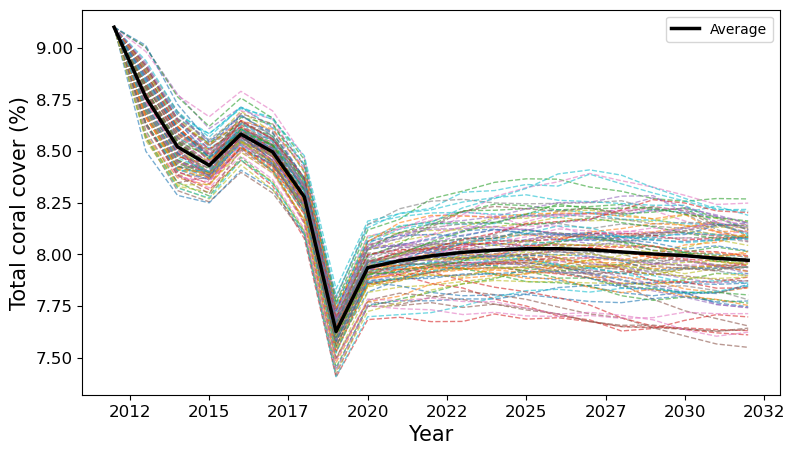

In [3]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

## Run the model through a number iterations for all parameters and export results

In [4]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            1.000000          2.900000        5.200000   
1      1            0.692819          2.934542        5.068174   
2      2            0.462600          2.938469        5.055117   
3      3            0.302869          2.981568        5.111077   
4      4            0.226195          3.049799        5.320680   
..   ...                 ...               ...             ...   
16    16            0.021795          3.522707        4.401371   
17    17            0.018261          3.576311        4.330195   
18    18            0.014726          3.624514        4.248513   
19    19            0.011683          3.668889        4.202469   
20    20            0.008639          3.730150        4.152007   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0                9.100000                90.200000                31.800000   
1                8.695536        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

In [5]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)


=== sediment_df ===


,Year,Month,Suspended_sediment,Deposited_sediment
0,2012,1,0.445200,7.319253
1,2012,2,0.840000,8.449960
2,2012,3,2.744689,13.904989
3,2012,4,5.291726,21.199703
4,2012,5,3.480261,16.011668



=== sediment_years ===
NOT FOUND

=== add_sedi_exp_per_year ===
{0: (19.01037599999998, 126.97611686399995),
 1: (16.455498000000002, 119.65894627199998),
 2: (14.588547, 114.31199860799998),
 3: (12.15290999999999, 107.33633423999997),
 4: (9.504099999999998, 99.7501424),
 5: (18.866363999999997, 104.39999999999999),
 6: (26.079710999999993, 126.70000000000002),
 7: (32.53330615735452, 200.09999999999997),
 8: (11.624253251615352, 94.2),
 9: (15.096299166666663, 104.39999999999999),
 10: (15.096299166666663, 104.39999999999999),
 11: (15.096299166666663, 104.39999999999999),
 12: (15.096299166666663, 104.39999999999999),
 13: (15.096299166666663, 104.39999999999999),
 14: (15.096299166666663, 104.39999999999999),
 15: (15.096299166666663, 104.39999999999999),
 16: (15.096299166666663, 104.39999999999999),
 17: (15.096299166666663, 104.39999999999999),
 18: (15.096299166666663, 104.39999999999999),
 19: (15.096299166666663, 104.39999999999999),
 20: (15.096299166666663, 104.3999999999

Saved figures to: output/figures as C2_2 Ge sedi event sp unknown 27112025_1x4_nobasel.png/.pdf/.svg


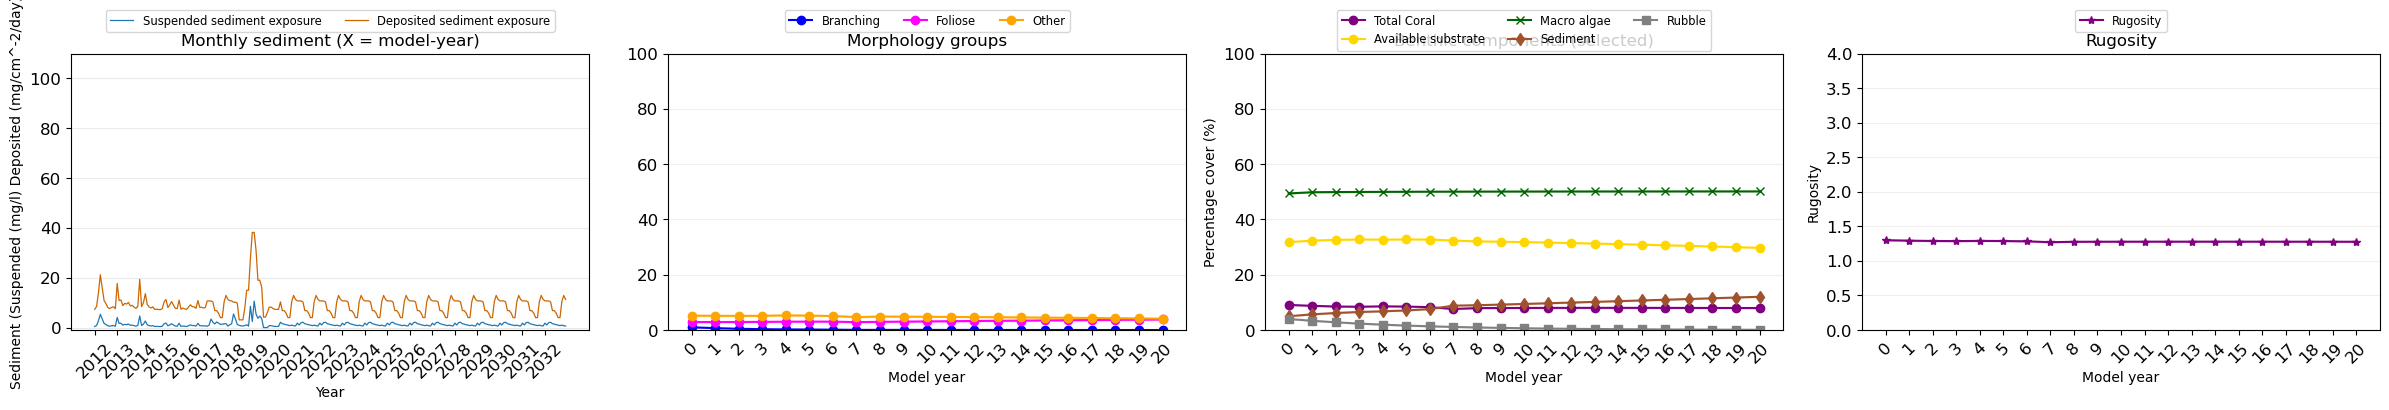

In [6]:
#plot above with real
#Version with new labels like those in Nikkis paper 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

MaxYear = int(globals().get('MaxYear'))
year_start = int(globals().get('year_start'))

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

model_x = np.arange(0, MaxYear + 1)
actual_years = model_x + year_start

fig, axs = plt.subplots(1, 4, figsize=(24, 5), sharey=False)
# ensure axs is iterable when ncols==1
if not hasattr(axs, "__iter__"):
    axs = [axs]

# --- Plot 1: Monthly sediment (X = model-year with month offset) ---
ax = axs[0]
sedi_src = globals().get('sedi_years', {}) or globals().get('sediment_df', {})
#baseline_suspended = float(globals().get('baseline_suspended_sediment', 0))
#baseline_deposited = float(globals().get('baseline_deposited_sediment', 0))

pts = []
if isinstance(sedi_src, dict):
    for k, v in sedi_src.items():
        try:
            if isinstance(k, (tuple, list)) and len(k) >= 2:
                ry = int(k[0]); m = int(k[1])
            else:
                continue
            if isinstance(v, (list, tuple)) and len(v) >= 2:
                suspended = float(v[0]); deposited = float(v[1])
            elif isinstance(v, dict):
                suspended = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                deposited = float(v.get('Deposited_sediment', v.get('deposited', 0)))
            else:
                suspended = float(v); deposited = 0.0
        except Exception:
            continue
        if 0 <= ry <= MaxYear:
            xpos = ry + (m - 1) / 12.0
            pts.append((xpos, suspended, deposited))

plot1_handles = []
plot1_labels = []
if not pts:
    ax.text(0.5, 0.5, "No monthly sediment data", ha='center', va='center', transform=ax.transAxes)
else:
    pts.sort(key=lambda p: p[0])
    xs = [p[0] for p in pts]
    suspended_y = [p[1] for p in pts]
    deposited_y = [p[2] for p in pts]

    # shift xs to calendar years (e.g. 2011..2031)
    xs_calendar = [x + year_start for x in xs]

    h1, = ax.plot(xs_calendar, suspended_y, color='tab:blue', linewidth=0.9, label='Suspended sediment exposure')
    h2, = ax.plot(xs_calendar, deposited_y, color='#CC6600', linewidth=0.9, label='Deposited sediment exposure') 
    # baseline horizontal lines with updated labels
    #hb = ax.axhline(baseline_suspended, color='navy', linestyle='--', linewidth=1.2, label='Baseline suspended sediment exposure')
    #hd = ax.axhline(baseline_deposited, color='darkorange', linestyle='--', linewidth=1.2, label='Baseline deposited sediment exposure')

    plot1_handles += [h1, h2]
    plot1_labels  = [h.get_label() for h in plot1_handles]

# IMPORTANT: x-axis should be calendar years (2011..2031)
ax.set_xlabel('Year')
ax.set_ylabel('Sediment (Suspended (mg/l) Deposited (mg/cm^-2/day)')  # per request
ax.set_title('Monthly sediment (X = model-year)')
ax.set_xticks(actual_years)
ax.set_xticklabels([str(x) for x in actual_years], rotation=45)
ax.set_ylim(-1, 110)   # changed lower bound to -1
ax.grid(axis='y', alpha=0.25)
# legend above this axis
if plot1_handles:
    ax.legend(plot1_handles, plot1_labels, loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize='small')

# --- Plot 2: Morphology groups (X = model_x) ---
ax = axs[1]
final_df = globals().get('final_df', None)

def mean_std_for(col):
    if isinstance(final_df, pd.DataFrame) and col in final_df.columns:
        s_mean = final_df.groupby('Year')[col].mean().reindex(model_x, fill_value=0).values
        s_std  = final_df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        s_mean = np.zeros_like(model_x, dtype=float)
        s_std = np.zeros_like(model_x, dtype=float)
    return s_mean, s_std

# compute mean and std for morphology groups
b_mean, b_std = mean_std_for('Branching_Area (%)')
f_mean, f_std = mean_std_for('Foliose_Area (%)')
o_mean, o_std = mean_std_for('Other_Area (%)')

hl_b, = ax.plot(model_x, b_mean, '-o', color='blue', label='Branching')
ax.fill_between(model_x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.2)
hl_f, = ax.plot(model_x, f_mean, '-o', color='fuchsia', label='Foliose')
ax.fill_between(model_x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.2)
hl_o, = ax.plot(model_x, o_mean, '-o', color='orange', label='Other')
ax.fill_between(model_x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.2)

ax.set_xlabel('Model year')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.grid(axis='y', alpha=0.2)
ax.legend([hl_b, hl_f, hl_o], ['Branching','Foliose','Other'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize='small')

# --- Plot 3: Benthic components (selected variables with SD shading) ---
ax = axs[2]
final_df = globals().get('final_df', None)

def mean_std_from_df(df, col):
    if isinstance(df, pd.DataFrame) and col in df.columns:
        m = df.groupby('Year')[col].mean().reindex(model_x, fill_value=np.nan).values
        s = df.groupby('Year')[col].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        m = np.full_like(model_x, np.nan, dtype=float)
        s = np.zeros_like(model_x, dtype=float)
    return m, s

# requested series
rubble_m, rubble_s = mean_std_from_df(final_df, 'rubble (%)')
coral_m,  coral_s  = mean_std_from_df(final_df, 'total_coral_cover (%)')
avail_m,  avail_s  = mean_std_from_df(final_df, 'available_substrate (%)')
macro_m,  macro_s  = mean_std_from_df(final_df, 'macro_algae (%)')
sed_m,    sed_s    = mean_std_from_df(final_df, 'sediment (%)')

# clear axis in case of re-run
ax.clear()

lines = []
# Coral cover (purple)
ln_cor, = ax.plot(model_x, coral_m, label='Total Coral', color='purple', marker='o')
ax.fill_between(model_x, coral_m - coral_s, coral_m + coral_s, color='purple', alpha=0.15)
lines.append(ln_cor)

# Available substrate (gold)
ln_av, = ax.plot(model_x, avail_m, label='Available substrate', color='gold', marker='o')
ax.fill_between(model_x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

# Macro algae (dark green)
ln_ma, = ax.plot(model_x, macro_m, label='Macro algae', color='darkgreen', marker='x')
ax.fill_between(model_x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_ma)

# Sediment (sienna)
ln_sed, = ax.plot(model_x, sed_m, label='Sediment', color='sienna', marker='d')
ax.fill_between(model_x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

# Rubble (gray)
ln_rub, = ax.plot(model_x, rubble_m, label='Rubble', color='gray', marker='s')
ax.fill_between(model_x, rubble_m - rubble_s, rubble_m + rubble_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ax.set_xlabel('Model year')
ax.set_ylabel('Percentage cover (%)')
ax.set_title('Benthic components (selected)')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.2)
ax.legend(lines, ['Total Coral','Available substrate','Macro algae','Sediment','Rubble'],
          loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=3, fontsize='small')

# --- Plot 4: Rugosity (with SD shading) ---
ax = axs[3]
try:
    if isinstance(final_df, pd.DataFrame) and 'Rugosity' in final_df.columns:
        rug_mean = final_df.groupby('Year')['Rugosity'].mean().reindex(model_x, fill_value=np.nan).values
        rug_std  = final_df.groupby('Year')['Rugosity'].std().reindex(model_x, fill_value=0).fillna(0).values
    else:
        # fallback to get_rugosity_list if available
        rl = list(globals().get('get_rugosity_list', lambda: [globals().get('Initial_Rugosity', 0.0)] * (MaxYear+1))())
        rug_mean = np.array((rl + [globals().get('Initial_Rugosity', 0.0)] * (MaxYear + 1))[:MaxYear+1], dtype=float)
        rug_std = np.zeros_like(rug_mean)
except Exception:
    rug_mean = np.zeros_like(model_x, dtype=float) + float(globals().get('Initial_Rugosity', 0.0))
    rug_std = np.zeros_like(rug_mean)

h_rug, = ax.plot(model_x, rug_mean, '-*', color='purple', label='Rugosity')
ax.fill_between(model_x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.2)
ax.set_xlabel('Model year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity')
ax.set_xticks(model_x)
ax.set_xticklabels([str(x) for x in model_x], rotation=45)
ax.set_ylim(0, max(4.0, np.nanmax(rug_mean) + 0.5))
ax.grid(axis='y', alpha=0.2)
ax.legend([h_rug], ['Rugosity'], loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=1, fontsize='small')
# adjust layout to allow space for all per-axis legends above plots
plt.tight_layout(rect=[0, 0, 1, 0.88])

basename = f'{title}_1x4_nobasel'
for ext in ('png', 'pdf', 'svg'):
    outpath = os.path.join(graph_dir, f"{basename}.{ext}")
    fig.savefig(outpath, dpi=200)

print(f"Saved figures to: {graph_dir} as {basename}.png/.pdf/.svg")
plt.show()
#

Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_legend.png


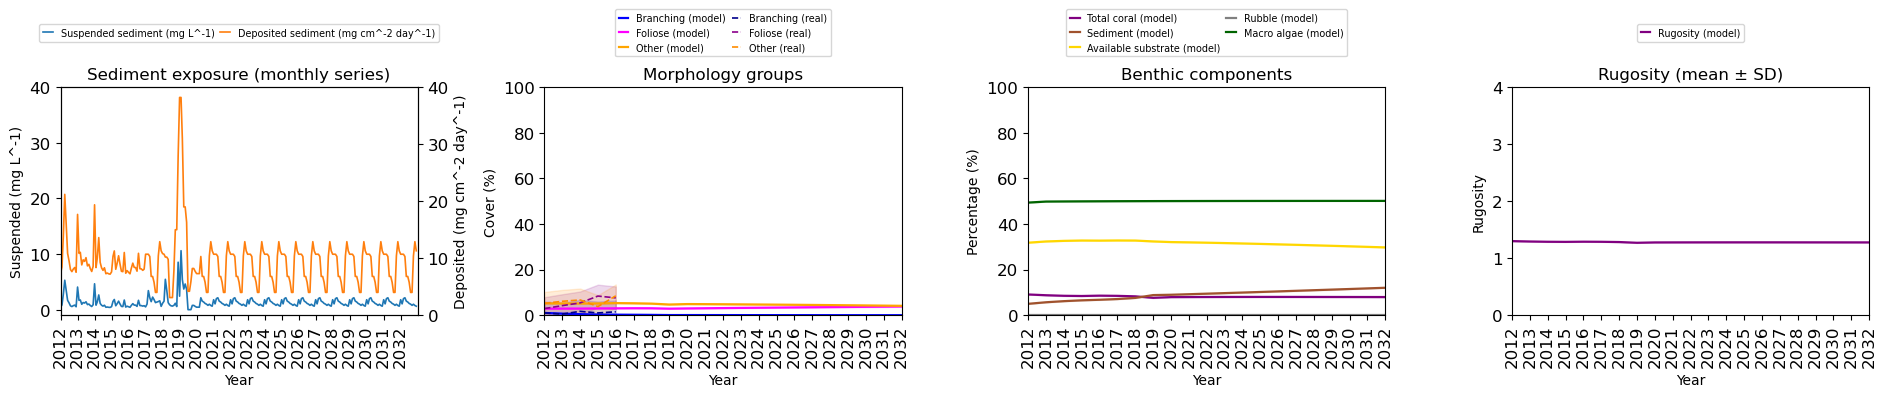

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

#
year_start = int(globals().get('year_start'))
year_end = int(globals().get('year_end'))
x = np.arange(year_start, year_end + 1)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))

ax.set_ylim(-1, 40)
ax2.set_ylim(0, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD + real (absolute ±5 cover)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

if isinstance(real_df, (list, tuple)) or hasattr(real_df, 'columns'):
    try:
        for col, color, lab in [
            ('RealBranching_Area (%)', 'darkblue', 'Branching (real)'),
            ('RealFoliose_Area (%)', 'darkmagenta', 'Foliose (real)'),
            ('RealOther_Area (%)',   'darkorange', 'Other (real)')
        ]:
            if real_df is not None and col in real_df.columns:
                yrs = real_df['Year'].astype(float).values
                vals = real_df[col].astype(float).values
                ax.plot(yrs, vals, color=color, linewidth=1.2, linestyle='--', label=lab)
                ax.fill_between(yrs, vals - 5.0, vals + 5.0, color=color, alpha=0.15)
    except Exception:
        pass

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD; compute total coral as sum(branching, foliose, other)
ax = axs[1, 2]
lines = []

# ensure arrays
_b = np.asarray(b_mean, dtype=float)
_bs = np.asarray(b_std, dtype=float)
_f = np.asarray(f_mean, dtype=float)
_fs = np.asarray(f_std, dtype=float)
_o = np.asarray(o_mean, dtype=float)
_os = np.asarray(o_std, dtype=float)

# total coral = branching + foliose + other; sd combined by sqrt(sum(var))
total_m = _b + _f + _o
total_s = np.sqrt(_bs**2 + _fs**2 + _os**2)

ln_total, = ax.plot(x, total_m, color='purple', linewidth=1.6, label='Total coral (model)')
ax.fill_between(x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ln_total)

ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_mac)

ax.set_ylim(0, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-4
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 4)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)

plt.show()


Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_legend.png


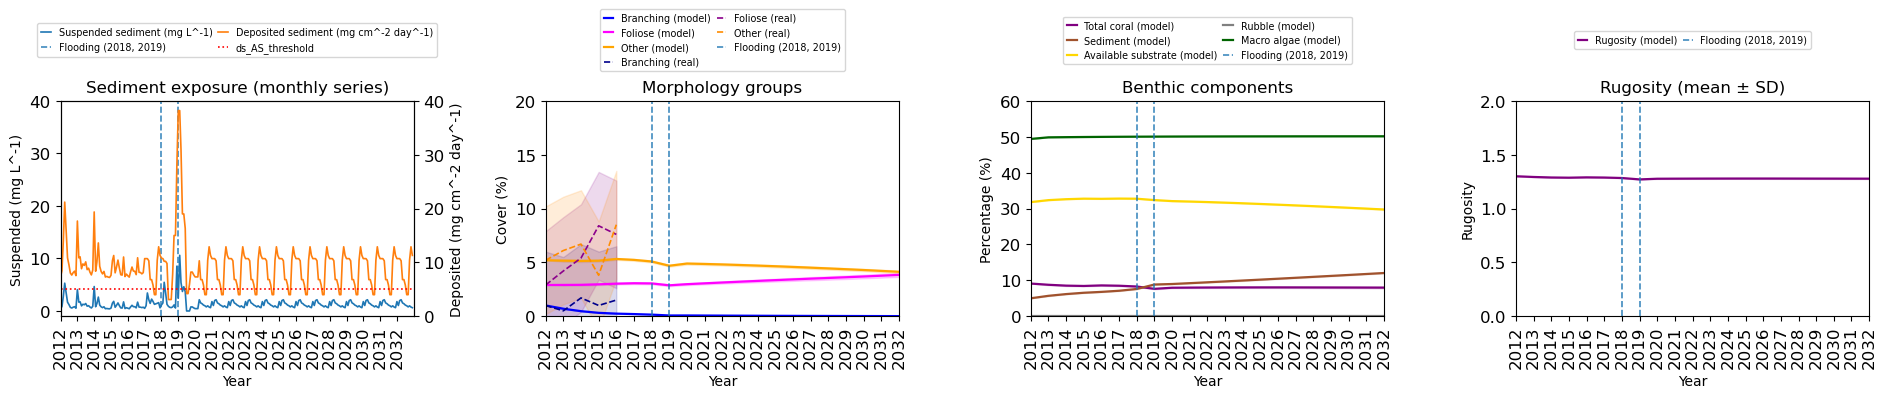

In [8]:
#adjusting for gbay - 

####adjusting plot above for GeBay

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

#
year_start = int(globals().get('year_start'))
year_end = int(globals().get('year_end'))
x = np.arange(year_start, year_end + 1)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# --- NEW: Flood markers & threshold settings ---
flood_years = [2018, 2019]
flood_color = 'tab:blue'
flood_kw = dict(color=flood_color, linestyle='--', linewidth=1.2, alpha=0.85)

def add_flood_markers(ax, is_date=False):
    """Add vertical dashed blue lines at flood_years."""
    for i, yr in enumerate(flood_years):
        label = 'Flooding (2018, 2019)' if i == 0 else None
        if is_date:
            ax.axvline(pd.Timestamp(f'{yr}-01-01'), label=label, **flood_kw)
        else:
            ax.axvline(yr, label=label, **flood_kw)

# Extract ds_AS_threshold for plot 1 (uses right y-axis: deposited sediment)
ds_AS_threshold = g.get('ds_AS_threshold', None)

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
    # --- NEW: flood markers on date axis
    add_flood_markers(ax, is_date=True)
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
    # --- NEW: flood markers on date axis
    add_flood_markers(ax, is_date=True)

# --- NEW: ds_AS_threshold horizontal line on right y-axis (if provided)
try:
    if ds_AS_threshold is not None and not (isinstance(ds_AS_threshold, float) and np.isnan(ds_AS_threshold)):
        ax2.axhline(float(ds_AS_threshold), color='red', linestyle=':', linewidth=1.2, label='ds_AS_threshold')
except Exception:
    pass

ax.set_ylim(-1, 40)
ax2.set_ylim(0, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD + real (absolute ±5 cover)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

if isinstance(real_df, (list, tuple)) or hasattr(real_df, 'columns'):
    try:
        for col, color, lab in [
            ('RealBranching_Area (%)', 'darkblue', 'Branching (real)'),
            ('RealFoliose_Area (%)', 'darkmagenta', 'Foliose (real)'),
            ('RealOther_Area (%)',   'darkorange', 'Other (real)')
        ]:
            if real_df is not None and col in real_df.columns:
                yrs = real_df['Year'].astype(float).values
                vals = real_df[col].astype(float).values
                ax.plot(yrs, vals, color=color, linewidth=1.2, linestyle='--', label=lab)
                ax.fill_between(yrs, vals - 5.0, vals + 5.0, color=color, alpha=0.15)
    except Exception:
        pass

# --- NEW: flood markers on numeric year axis
add_flood_markers(ax, is_date=False)

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups')
ax.set_ylim(0, 20)  # NEW: requested scale
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD; compute total coral as sum(branching, foliose, other)
ax = axs[1, 2]
lines = []

# ensure arrays
_b = np.asarray(b_mean, dtype=float)
_bs = np.asarray(b_std, dtype=float)
_f = np.asarray(f_mean, dtype=float)
_fs = np.asarray(f_std, dtype=float)
_o = np.asarray(o_mean, dtype=float)
_os = np.asarray(o_std, dtype=float)

# total coral = branching + foliose + other; sd combined by sqrt(sum(var))
total_m = _b + _f + _o
total_s = np.sqrt(_bs**2 + _fs**2 + _os**2)

ln_total, = ax.plot(x, total_m, color='purple', linewidth=1.6, label='Total coral (model)')
ax.fill_between(x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ln_total)

ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_mac)

# --- NEW: flood markers on numeric year axis
add_flood_markers(ax, is_date=False)

ax.set_ylim(0, 60)  # NEW: requested scale
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-2 (NEW)
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)

# --- NEW: flood markers on numeric year axis
add_flood_markers(ax, is_date=False)

ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 2)  # NEW: requested scale
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)



Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_legend.png


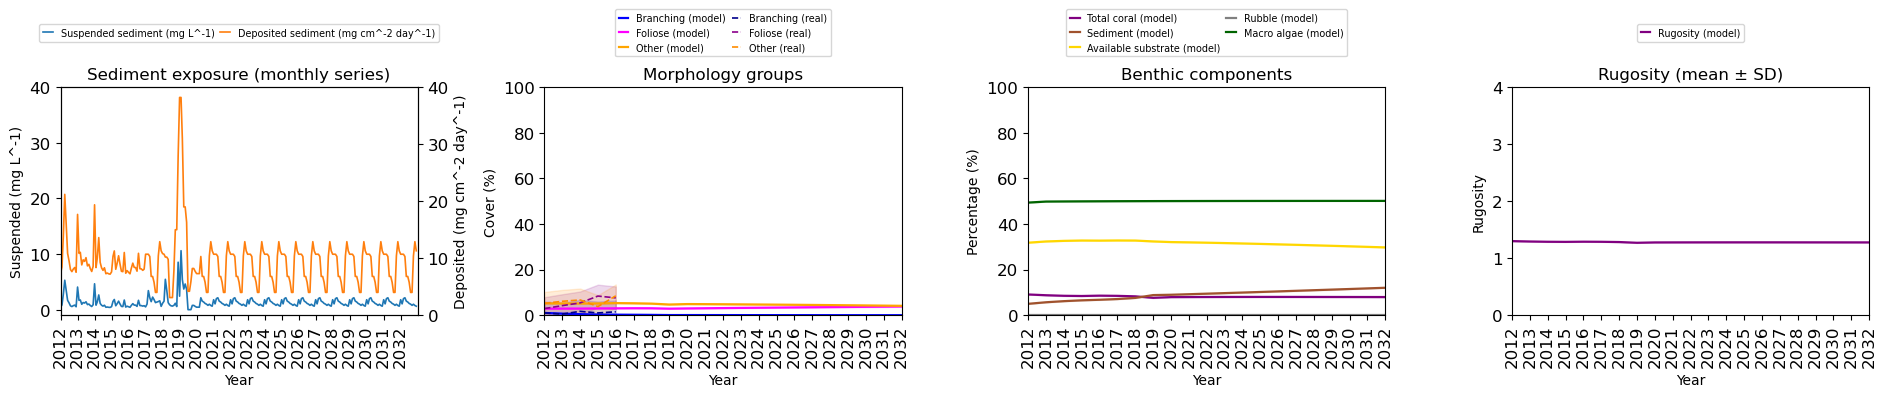

In [9]:
####adjusting plot above for GeBay

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

#
year_start = int(globals().get('year_start'))
year_end = int(globals().get('year_end'))
x = np.arange(year_start, year_end + 1)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))

ax.set_ylim(-1, 40)
ax2.set_ylim(0, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD + real (absolute ±5 cover)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

if isinstance(real_df, (list, tuple)) or hasattr(real_df, 'columns'):
    try:
        for col, color, lab in [
            ('RealBranching_Area (%)', 'darkblue', 'Branching (real)'),
            ('RealFoliose_Area (%)', 'darkmagenta', 'Foliose (real)'),
            ('RealOther_Area (%)',   'darkorange', 'Other (real)')
        ]:
            if real_df is not None and col in real_df.columns:
                yrs = real_df['Year'].astype(float).values
                vals = real_df[col].astype(float).values
                ax.plot(yrs, vals, color=color, linewidth=1.2, linestyle='--', label=lab)
                ax.fill_between(yrs, vals - 5.0, vals + 5.0, color=color, alpha=0.15)
    except Exception:
        pass

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD; compute total coral as sum(branching, foliose, other)
ax = axs[1, 2]
lines = []

# ensure arrays
_b = np.asarray(b_mean, dtype=float)
_bs = np.asarray(b_std, dtype=float)
_f = np.asarray(f_mean, dtype=float)
_fs = np.asarray(f_std, dtype=float)
_o = np.asarray(o_mean, dtype=float)
_os = np.asarray(o_std, dtype=float)

# total coral = branching + foliose + other; sd combined by sqrt(sum(var))
total_m = _b + _f + _o
total_s = np.sqrt(_bs**2 + _fs**2 + _os**2)

ln_total, = ax.plot(x, total_m, color='purple', linewidth=1.6, label='Total coral (model)')
ax.fill_between(x, total_m - total_s, total_m + total_s, color='purple', alpha=0.15)
lines.append(ln_total)

ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)
lines.append(ln_sed)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)
lines.append(ln_av)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)
lines.append(ln_rub)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)
lines.append(ln_mac)

ax.set_ylim(0, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-4
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 4)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)

plt.show()


Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_4panel_2000_2020_wide_with_keys.png
Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_legend.png


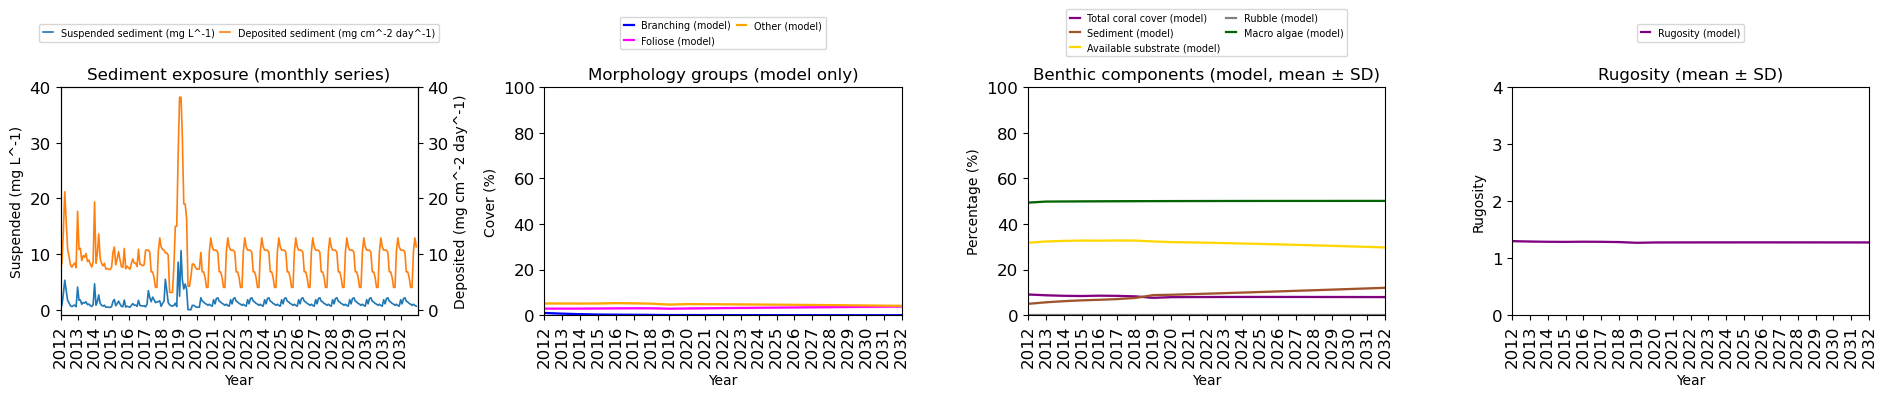

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)

# x axis 2011-2031 (inclusive)
year_start = int(globals().get('year_start'))
year_end = int(globals().get('year_end'))
x = np.arange(year_start, year_end + 1)

g = globals()

def safe_series(name, fallback=None):
    v = g.get(name, fallback)
    if v is None:
        return np.full(len(x), np.nan)
    arr = np.asarray(v, dtype=float)
    if arr.size == len(x):
        return arr
    if arr.size > len(x):
        return arr[:len(x)]
    return np.concatenate([arr, np.full(len(x) - arr.size, np.nan)])

# Build annual suspended/deposited from sedi_years / sedi_src as fallback (kept for compatibility)
sedi_src = g.get('sedi_years', g.get('sedi_src', None))
suspended_year = np.zeros(len(x))
deposited_year = np.zeros(len(x))
counts = np.zeros(len(x))
if isinstance(sedi_src, dict):
    for (ry, m), v in sedi_src.items():
        if 0 <= int(ry) <= 20:
            idx = int(ry)
            try:
                if isinstance(v, (list, tuple)) and len(v) >= 2:
                    susp = float(v[0]); dep = float(v[1])
                elif isinstance(v, dict):
                    susp = float(v.get('Suspended_sediment', v.get('suspended', 0)))
                    dep  = float(v.get('Deposited_sediment', v.get('deposited', 0)))
                else:
                    susp = float(v); dep = 0.0
            except Exception:
                continue
            suspended_year[idx] += susp
            deposited_year[idx] += dep
            counts[idx] += 1
mask = counts > 0
suspended_year[mask] /= counts[mask]
deposited_year[mask] /= counts[mask]
if not mask.any():
    suspended_year = safe_series('sed_m', np.zeros(len(x)))
    deposited_year = safe_series('sed_m', np.zeros(len(x)))

# Morphology groups
b_mean = safe_series('b_mean', np.zeros(len(x)))
b_std  = safe_series('b_std', np.zeros(len(x)))
f_mean = safe_series('f_mean', np.zeros(len(x)))
f_std  = safe_series('f_std', np.zeros(len(x)))
o_mean = safe_series('o_mean', np.zeros(len(x)))
o_std  = safe_series('o_std', np.zeros(len(x)))
real_df = g.get('real_df', None)  # kept but not plotted

# Benthic components
t_mean = safe_series('t_mean', np.zeros(len(x)))
t_std  = safe_series('t_std', np.zeros(len(x)))
sed_m  = safe_series('sed_m', np.zeros(len(x)))
sed_s  = safe_series('sed_s', np.zeros(len(x)))
rb_m   = safe_series('rb_m', np.zeros(len(x)))
rb_s   = safe_series('rb_s', np.zeros(len(x)))
bent_mean = g.get('bent_mean', {})
bent_std  = g.get('bent_std', {})
avail_m = np.asarray(bent_mean.get('avail', safe_series('avail_m', np.zeros(len(x)))), dtype=float)
avail_s = np.asarray(bent_std.get('avail', safe_series('avail_s', np.zeros(len(x)))), dtype=float)
macro_m = np.asarray(bent_mean.get('macro', safe_series('macro_m', np.zeros(len(x)))), dtype=float)
macro_s = np.asarray(bent_std.get('macro', safe_series('macro_s', np.zeros(len(x)))), dtype=float)

# Rugosity
rug_mean = safe_series('rug_mean', np.full(len(x), np.nan))
rug_std  = safe_series('rug_std', np.zeros(len(x)))

# Create 2x4 layout — top row for keys, bottom row for the 4 plots
subplot_width = 4.6  # inches per subplot (increased to make plots wider)
fig_w = subplot_width * 4 + 0.6
bottom_height = 3.6
top_height = 0.6
fig_h = top_height + bottom_height
# height_ratios: small top row, larger bottom row
fig, axs = plt.subplots(2, 4, figsize=(fig_w, fig_h), gridspec_kw={'height_ratios': [top_height, bottom_height]})
plt.subplots_adjust(wspace=0.35, hspace=0.08, bottom=0.06)

# top-row axes (legend cells) are axs[0, :]
legend_cells = axs[0, :]

# smaller legend (keys) settings
legend_kwargs = dict(fontsize='x-small', markerscale=0.8, handlelength=1.0, columnspacing=0.6)

# Plot 1: monthly sediment (suspended & deposited) but label per year
ax = axs[1, 0]
ax2 = ax.twinx()

sed_df = g.get('sediment_df', None)
if isinstance(sed_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sed_df.columns):
    # create datetime index for monthly data
    dates = pd.to_datetime(dict(year=sed_df['Year'], month=sed_df['Month'], day=1))
    susp_monthly = sed_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sed_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited sediment (mg cm^-2 day^-1)')
    # put ticks at each year Jan 1
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended sediment (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited sediment (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xticks(years_dt)
    ax.set_xlim(pd.Timestamp(f'{x[0]}-01-01'), pd.Timestamp(f'{x[-1]}-12-31'))

ax.set_ylim(-1, 40)
ax2.set_ylim(-1, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')  # added year label to plot1 x axis
ax.tick_params(axis='x', rotation=90)

# Plot 2: Morphology groups with SD (model values only)
ax = axs[1, 1]
h_b, = ax.plot(x, b_mean, color='blue', linewidth=1.6, label='Branching (model)')
ax.fill_between(x, b_mean - b_std, b_mean + b_std, color='blue', alpha=0.18)
h_f, = ax.plot(x, f_mean, color='fuchsia', linewidth=1.6, label='Foliose (model)')
ax.fill_between(x, f_mean - f_std, f_mean + f_std, color='fuchsia', alpha=0.18)
h_o, = ax.plot(x, o_mean, color='orange', linewidth=1.6, label='Other (model)')
ax.fill_between(x, o_mean - o_std, o_mean + o_std, color='orange', alpha=0.18)

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Morphology groups (model only)')
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 3: Benthic components with SD (plot standard deviation) and total coral cover computed from morphology
ax = axs[1, 2]

# ensure component arrays
branch_m = np.asarray(b_mean, dtype=float)
branch_s = np.asarray(b_std, dtype=float)
folio_m  = np.asarray(f_mean, dtype=float)
folio_s  = np.asarray(f_std, dtype=float)
other_m  = np.asarray(o_mean, dtype=float)
other_s  = np.asarray(o_std, dtype=float)

# compute total coral cover (use morphology groups rather than t_mean which may be incorrect)
total_mean = branch_m + folio_m + other_m
# assume independence and combine variances for std (sqrt(sum variances))
total_std = np.sqrt(branch_s**2 + folio_s**2 + other_s**2)

# Plot total coral cover (mean ± SD)
ln_total, = ax.plot(x, total_mean, color='purple', linewidth=1.6, label='Total coral cover (model)')
ax.fill_between(x, total_mean - total_std, total_mean + total_std, color='purple', alpha=0.15)

# Plot other benthic components with their SD
ln_sed, = ax.plot(x, sed_m, color='sienna', linewidth=1.6, label='Sediment (model)')
ax.fill_between(x, sed_m - sed_s, sed_m + sed_s, color='sienna', alpha=0.15)

ln_av, = ax.plot(x, avail_m, color='gold', linewidth=1.6, label='Available substrate (model)')
ax.fill_between(x, avail_m - avail_s, avail_m + avail_s, color='gold', alpha=0.15)

ln_rub, = ax.plot(x, rb_m, color='gray', linewidth=1.6, label='Rubble (model)')
ax.fill_between(x, rb_m - rb_s, rb_m + rb_s, color='gray', alpha=0.15)

ln_mac, = ax.plot(x, macro_m, color='darkgreen', linewidth=1.6, label='Macro algae (model)')
ax.fill_between(x, macro_m - macro_s, macro_m + macro_s, color='darkgreen', alpha=0.15)

ax.set_ylim(0, 100)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('Benthic components (model, mean ± SD)')
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Plot 4: Rugosity with SD, y axis 0-4
ax = axs[1, 3]
ln_rug, = ax.plot(x, rug_mean, color='purple', linewidth=1.6, label='Rugosity (model)')
ax.fill_between(x, rug_mean - rug_std, rug_mean + rug_std, color='purple', alpha=0.18)
ax.set_xlabel('Year')
ax.set_ylabel('Rugosity')
ax.set_title('Rugosity (mean ± SD)')
ax.set_ylim(0, 4)
ax.set_xticks(x)
ax.set_xlim(x[0], x[-1])
ax.tick_params(axis='x', rotation=90)

# Place legends (keys) in the top row cells, one per column, showing the legend for the bottom plot below it.
bottom_axes = axs[1, :]
# For the first column include the twin axis (ax2)
for col in range(4):
    top_ax = legend_cells[col]
    top_ax.axis('off')
    if col == 0:
        # get handles from bottom plot 1 and its twin axis
        bot_ax = bottom_axes[col]
        h1, l1 = bot_ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        handles = h1 + h2
        labels = l1 + l2
    else:
        bot_ax = bottom_axes[col]
        handles, labels = bot_ax.get_legend_handles_labels()
    # keep labels unique in order
    unique_h = []
    unique_l = []
    for hh, ll in zip(handles, labels):
        if ll and ll not in unique_l:
            unique_h.append(hh)
            unique_l.append(ll)
    if unique_h:
        ncol = min(2, max(1, len(unique_l)))
        top_ax.legend(unique_h, unique_l, loc='center', ncol=ncol, **legend_kwargs)

# Improve overall layout: use tight layout for axes spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.98])

# Save main figure (without legend)
fname_main = os.path.join(graph_dir, f"{g.get('title','run')}_4panel_2000_2020_wide_with_keys.png")
fig.savefig(fname_main, dpi=200, bbox_inches='tight')
print(f"Saved {fname_main}")

# Optionally create separate combined legend as before (collect from bottom axes only)
all_handles = []
all_labels = []
# include twin axes handles for column 0
for a in list(bottom_axes) + [ax2]:
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in all_labels:
            all_handles.append(hh)
            all_labels.append(ll)

if all_handles:
    ncol = min(4, max(1, len(all_labels)))
    fig_legend = plt.figure(figsize=(max(6, ncol * 2.5), 1.2))
    fig_legend.legend(all_handles, all_labels, loc='center', ncol=ncol, **legend_kwargs)
    plt.axis('off')
    fname_legend = os.path.join(graph_dir, f"{g.get('title','run')}_legend.png")
    fig_legend.savefig(fname_legend, dpi=200, bbox_inches='tight')
    print(f"Saved {fname_legend}")
    plt.close(fig_legend)

plt.show()


Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_recruits_and_psd_summary.png


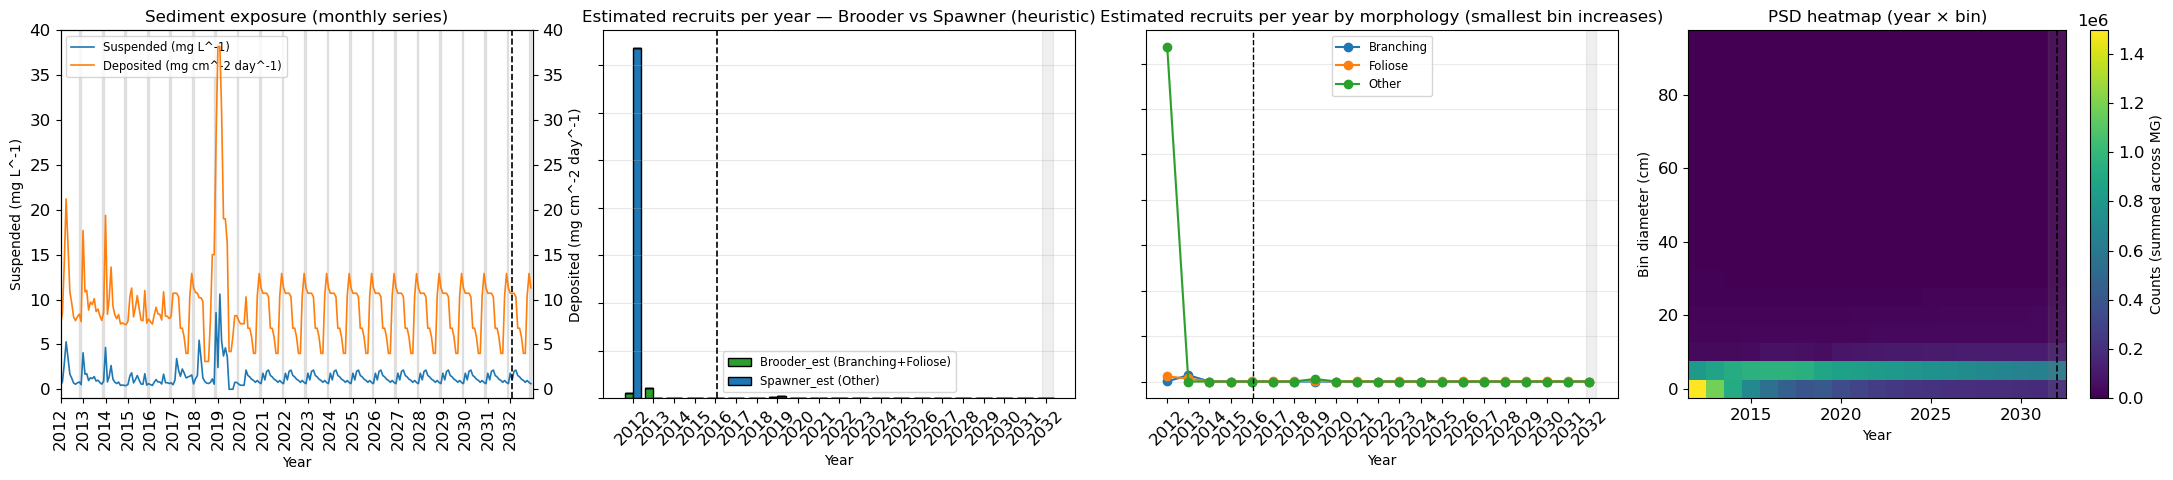

Saved output/figures\C2_2 Ge sedi event sp unknown 27112025_recruits_and_psd_summary.png


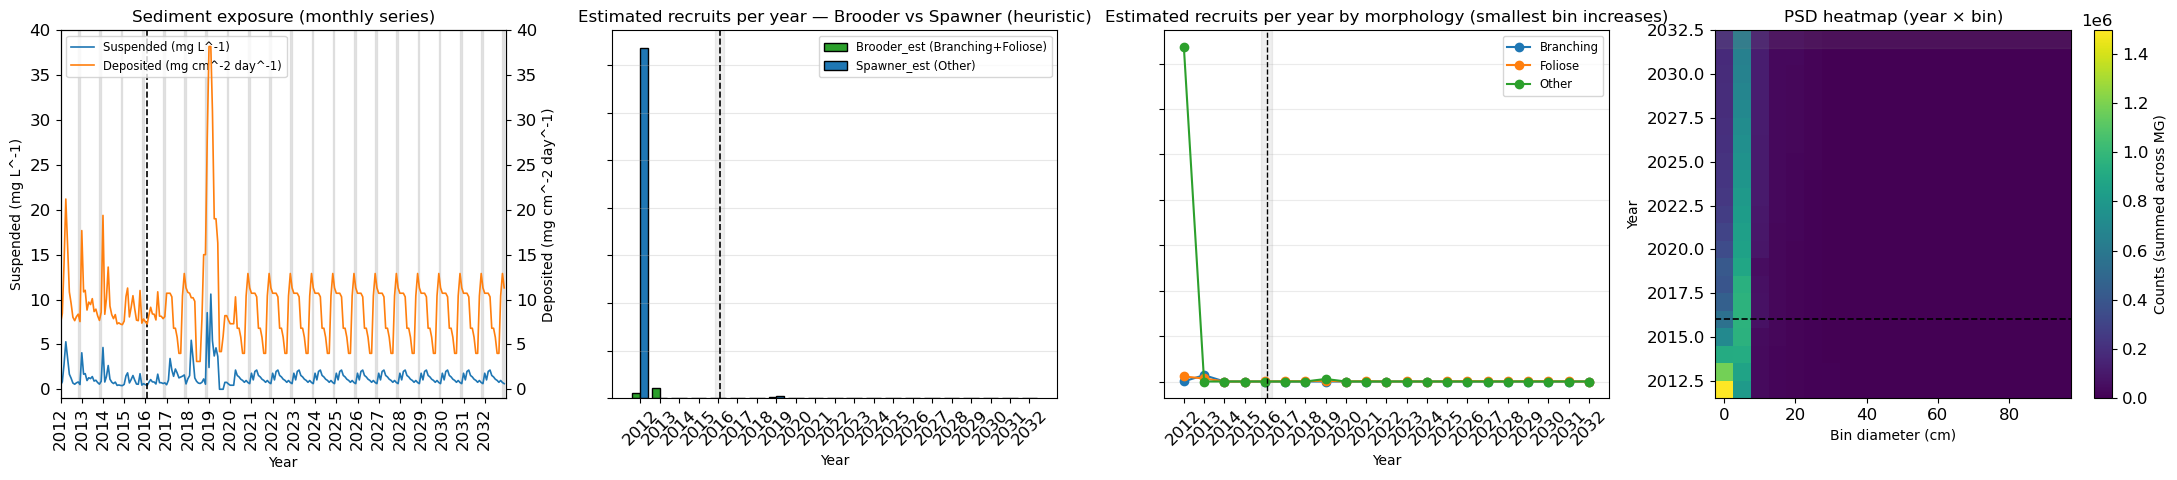

In [11]:
import builtins, sys, importlib, os
# target month/year for the event marker (month=2 -> February 2016)
_EVENT_MARKER_YEAR = 2016
_EVENT_MARKER_MONTH = 2
import numpy as np
_np = np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthEnd

# Patch imports so we can modify pandas Timestamp and matplotlib Axes behavior

_orig_import = builtins.__import__
_targets = {'pandas', 'matplotlib'}
_patched = set()

def _custom_import(name, globals_, locals_, fromlist, level=0):
    mod = _orig_import(name, globals_, locals_, fromlist, level)
    base = name.split('.')[0]

    # Patch pandas.Timestamp so that any Timestamp created from a "-02-01" string
    # becomes February 2016 (user requested dashed line at month 2 2016).
    if base == 'pandas' and 'pandas' not in _patched:
        try:
            pd_mod = sys.modules.get('pandas', mod)
            orig_ts = getattr(pd_mod, 'Timestamp', None)
            if orig_ts is not None:
                def _patched_Timestamp(arg=None, *a, **k):
                    # only override strings that represent a Feb-01 date
                    if isinstance(arg, str) and arg.endswith('-02-01'):
                        return orig_ts('2016-02-01')
                    return orig_ts(arg, *a, **k)
                pd_mod.Timestamp = _patched_Timestamp
            _patched.add('pandas')
        except Exception:
            pass

    # Patch matplotlib Axes methods to:
    # - amend y-axis labels "Estimated new recruits (count)" -> add "± SD"
    # - add SD/errorbars to bars labeled Brooder/Spawner
    # - add shaded ±SD bands for morphology lines (Branching/Foliose/Other)
    # - remap numeric vertical lines drawn at (year_end + (2-1)/12) to Feb 2016
    if base == 'matplotlib' and 'matplotlib' not in _patched:
        try:
            # ensure matplotlib package is loaded
            mat = sys.modules.get('matplotlib') or importlib.import_module('matplotlib')
            axes_mod = importlib.import_module('matplotlib.axes')
            Axes = getattr(axes_mod, '_axes').Axes

            # set_ylabel wrapper: change specific label text to include ± SD
            _orig_set_ylabel = Axes.set_ylabel
            def _set_ylabel(self, label, *a, **k):
                try:
                    if isinstance(label, str) and label.strip() == 'Estimated new recruits (count)':
                        label = 'Estimated new recruits (count ± SD)'
                except Exception:
                    pass
                return _orig_set_ylabel(self, label, *a, **k)
            Axes.set_ylabel = _set_ylabel

            # axvline: remap marker at computed year_end+(2-1)/12 to Feb 2016 numeric
            _orig_axvline = Axes.axvline
            def _axvline(self, x=0, *a, **k):
                try:
                    G = globals()
                    ye = G.get('year_end', None)
                    if ye is not None and isinstance(x, (int, float)):
                        target = ye + (2 - 1) / 12.0
                        if abs(x - target) < 1e-6:
                            x = 2016 + (2 - 1) / 12.0
                except Exception:
                    pass
                return _orig_axvline(self, x, *a, **k)
            Axes.axvline = _axvline

            # axhline: remap horizontal line plotted at year_end to 2016
            _orig_axhline = Axes.axhline
            def _axhline(self, y=0, *a, **k):
                try:
                    G = globals()
                    ye = G.get('year_end', None)
                    if ye is not None and isinstance(y, (int, float)):
                        if abs(y - ye) < 1e-6:
                            y = 2016
                except Exception:
                    pass
                return _orig_axhline(self, y, *a, **k)
            Axes.axhline = _axhline

            # bar: after drawing bars, add errorbars for Brooder and Spawner estimates
            _orig_bar = Axes.bar
            def _bar(self, x, height, *a, **kw):
                bars = _orig_bar(self, x, height, *a, **kw)
                try:
                    lab = kw.get('label', '')
                    G = globals()
                    recruits_total = G.get('recruits_per_year', None)
                    recruits_morph = G.get('recruits_per_morph', None)
                    std = G.get('std', None)
                    if recruits_total is not None and recruits_morph is not None and std is not None and isinstance(lab, str):
                        total = recruits_total.values if hasattr(recruits_total, 'values') else _np.array(recruits_total)
                        if 'Brooder' in lab:
                            br = (recruits_morph['Branching'].values + recruits_morph['Foliose'].values)
                            yerr = _np.array(std) * (br / (total + 1e-9))
                            self.errorbar(x, height, yerr=yerr, fmt='none', ecolor='k', capsize=3)
                        if 'Spawner' in lab:
                            oth = recruits_morph['Other'].values
                            yerr = _np.array(std) * (oth / (total + 1e-9))
                            self.errorbar(x, height, yerr=yerr, fmt='none', ecolor='k', capsize=3)
                except Exception:
                    pass
                return bars
            Axes.bar = _bar

            # plot: after plotting morphology lines, add shaded ±SD bands
            _orig_plot = Axes.plot
            def _plot(self, *a, **kw):
                lines = _orig_plot(self, *a, **kw)
                try:
                    lab = kw.get('label', None)
                    G = globals()
                    recruits_morph = G.get('recruits_per_morph', None)
                    recruits_total = G.get('recruits_per_year', None)
                    std = G.get('std', None)
                    years_actual = G.get('years_actual', None)
                    if (lab in ('Branching', 'Foliose', 'Other') and
                        recruits_morph is not None and recruits_total is not None and std is not None and years_actual is not None):
                        morph_vals = recruits_morph[lab].values
                        total = recruits_total.values if hasattr(recruits_total, 'values') else _np.array(recruits_total)
                        morph_sd = _np.array(std) * (morph_vals / (total + 1e-9))
                        # ensure color is taken from the plotted line
                        color = lines[0].get_color() if lines else None
                        self.fill_between(years_actual, morph_vals - morph_sd, morph_vals + morph_sd,
                                          color=color, alpha=0.12)
                except Exception:
                    pass
                return lines
            Axes.plot = _plot

            _patched.add('matplotlib')
        except Exception:
            pass

    # If we've patched all targets we care about, restore the original import
    if _patched >= _targets:
        builtins.__import__ = _orig_import

    return mod

# install the import hook
builtins.__import__ = _custom_import

# --- helpers / gather globals ---
g = globals()
year_start = int(g.get('year_start'))
year_end   = int(g.get('year_end'))
x_years = np.arange(year_start, year_end + 1)

pop_df = g.get('population_size_df')                 # absolute counts per MG/year/bin
perc_pop_df = g.get('percentage_population_size_df') # percentage per MG/year/bin
sediment_df = g.get('sediment_df', None)
suspended_year = np.asarray(g.get('suspended_year', np.zeros_like(x_years)), dtype=float)
deposited_year  = np.asarray(g.get('deposited_year', np.zeros_like(x_years)), dtype=float)

# identify bin columns (assume pattern 'Bin Diameter' used earlier)
all_cols = pop_df.columns.tolist() if pop_df is not None else []
bin_cols = [c for c in all_cols if c.startswith('Bin Diameter')]
if not bin_cols:
    raise RuntimeError("No 'Bin Diameter' columns found in population_size_df")

# first (smallest) bin used as recruit-class
small_bin = bin_cols[0]

# spawn-month info
spawn_known = bool(g.get('spawning_month_known', False))
spawn_month = int(g.get('spawning_month', 1)) if spawn_known else None

# Feb 2026 vertical marker (user requested month 2 of 2026)
marker_dt = pd.Timestamp(f"{year_end}-02-01")

# --- compute recruit estimates per year ---
# We approximate recruits as positive year-to-year increases in the smallest bin.
# per morphology group
if pop_df is None:
    raise RuntimeError("population_size_df not available in notebook globals")

# pivot: Year x MG aggregated count in smallest bin
small_bin_df = pop_df[['MG', 'Year', small_bin]].copy()
# ensure Year numeric
small_bin_df['Year'] = small_bin_df['Year'].astype(int)
# build time-series per MG
recr_by_mg = small_bin_df.pivot_table(index='Year', columns='MG', values=small_bin, aggfunc='sum').reindex(range(0, year_end-year_start+1)).fillna(0)
# positive increases => new recruits
recruits_diff = recr_by_mg.diff().fillna(recr_by_mg.iloc[0]).clip(lower=0)

# estimate brooders vs spawners:
# heuristic: brooders produce local small recruits (Branching + Foliose),
# spawners contribute to Other (this is an approximation)
brooder_est = recruits_diff.get('Branching', 0) + recruits_diff.get('Foliose', 0)
spawner_est = recruits_diff.get('Other', 0)

# recruits per morphology (sum positives)
recruits_per_morph = recruits_diff  # DataFrame: rows = model-year index (0..), cols = MG

# PSD heatmap: sum absolute counts across MG per year across bins
# build Year x Bin matrix from population_size_df rows (MG, Year)
psd_counts = pop_df.groupby('Year')[bin_cols].sum().reindex(range(0, year_end-year_start+1)).fillna(0).values
# convert model-year indices to actual years for plotting
psd_years = np.arange(year_start, year_start + psd_counts.shape[0])

# --- plotting 4-panel figure ---
fig, axs = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=False)

# ---- Plot 1: monthly sediment series (datetime x) ----
ax = axs[0]
ax2 = ax.twinx()

if isinstance(sediment_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sediment_df.columns):
    dates = pd.to_datetime(dict(year=sediment_df['Year'], month=sediment_df['Month'], day=1))
    susp_monthly = sediment_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sediment_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.Timestamp(f'{x_years[0]}-01-01'), pd.Timestamp(f'{x_years[-1]}-12-31'))
    # shade spawn-month(s)
    if spawn_known:
        for yr in range(year_start, year_end + 1):
            start = pd.Timestamp(f"{yr}-{spawn_month:02d}-01")
            end = (start + MonthEnd(1))
            ax.axvspan(start, end, color='gray', alpha=0.18)
    else:
        # unknown: subtle full-month grid shading (here we shade every month lightly)
        ax.axvspan(pd.Timestamp(f'{year_start}-01-01'), pd.Timestamp(f'{year_end}-12-31'), color='gray', alpha=0.06)
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x_years]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.Timestamp(f'{x_years[0]}-01-01'), pd.Timestamp(f'{x_years[-1]}-12-31'))
    # shading for spawn-month: convert month into year-wide thin band near that month
    if spawn_known:
        for yr in range(year_start, year_end + 1):
            start = pd.Timestamp(f"{yr}-{spawn_month:02d}-01")
            ax.axvspan(start, start + MonthEnd(1), color='gray', alpha=0.18)
    else:
        ax.axvspan(pd.Timestamp(f'{year_start}-01-01'), pd.Timestamp(f'{year_end}-12-31'), color='gray', alpha=0.06)

# dashed vertical marker at Feb of year_end
ax.axvline(marker_dt, color='k', linestyle='--', linewidth=1.2)
ax.set_ylim(-1, 40)
ax2.set_ylim(-1, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=90)
# combined legend
handles = []
labels = []
for a in (ax, ax2):
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh); labels.append(ll)
ax.legend(handles, labels, loc='upper left', fontsize='small')

# ---- Plot 2: recruits per year by source (brooder vs spawner estimate) ----
ax = axs[1]
years_model = np.arange(0, recruits_diff.shape[0])
years_actual = years_model + year_start
brooder_vals = brooder_est.values if hasattr(brooder_est, 'values') else np.zeros_like(years_actual)
spawner_vals = spawner_est.values if hasattr(spawner_est, 'values') else np.zeros_like(years_actual)

# compute per-year SD propagation for sources using global std and total recruits
std_arr = np.asarray(g.get('std', np.zeros_like(years_actual)))
total = g.get('recruits_per_year').values if g.get('recruits_per_year') is not None else (brooder_vals + spawner_vals)
total = np.asarray(total)
eps = 1e-9
brooder_yerr = std_arr * (brooder_vals / (total + eps))
spawner_yerr = std_arr * (spawner_vals / (total + eps))

bar_w = 0.4
bar1 = ax.bar(years_actual - bar_w/2, brooder_vals, width=bar_w, label='Brooder_est (Branching+Foliose)', color='tab:green', edgecolor='k')
bar2 = ax.bar(years_actual + bar_w/2, spawner_vals, width=bar_w, label='Spawner_est (Other)', color='tab:blue', edgecolor='k')
# add errorbars for each bar group
ax.errorbar(years_actual - bar_w/2, brooder_vals, yerr=brooder_yerr, fmt='none', ecolor='k', capsize=3)
ax.errorbar(years_actual + bar_w/2, spawner_vals, yerr=spawner_yerr, fmt='none', ecolor='k', capsize=3)

# vertical marker at Feb of event year (as fractional year)
marker_x = year_end + (2-1)/12.0
ax.axvline(marker_x, color='k', linestyle='--', linewidth=1.2)
# shading: if spawn month known shade that month (we shade the year band at spawn month position)
if spawn_known:
    ax.axvspan(marker_x - 0.25, marker_x + 0.25, color='gray', alpha=0.12)
else:
    ax.axvspan(years_actual[0]-0.5, years_actual[-1]+0.5, color='gray', alpha=0.04)

ax.set_xlabel('Year'); ax.set_ylabel('Estimated new recruits (count ± SD)')
ax.set_title('Estimated recruits per year — Brooder vs Spawner (heuristic)')
ax.set_xticks(years_actual); ax.set_xticklabels([str(int(y)) for y in years_actual], rotation=45)
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.3)

# ---- Plot 3: recruits per year per morphology (Branching/Foliose/Other) ----
ax = axs[2]
total_arr = total
for i, col in enumerate(recruits_per_morph.columns):
    vals = recruits_per_morph[col].values
    # compute morphology-specific SD band from std and fraction of total recruits
    morph_yerr = std_arr * (vals / (total_arr + eps))
    ln, = ax.plot(years_actual, vals, '-o', label=col)
    # shaded ±SD
    color = ln.get_color()
    ax.fill_between(years_actual, vals - morph_yerr, vals + morph_yerr, color=color, alpha=0.12)

# add marker + shading
ax.axvline(marker_x, color='k', linestyle='--', linewidth=1.0)
if spawn_known:
    ax.axvspan(marker_x - 0.25, marker_x + 0.25, color='gray', alpha=0.12)
else:
    ax.axvspan(years_actual[0]-0.5, years_actual[-1]+0.5, color='gray', alpha=0.04)

ax.set_xlabel('Year'); ax.set_ylabel('Estimated new recruits (count ± SD)')
ax.set_title('Estimated recruits per year by morphology (smallest bin increases)')
ax.set_xticks(years_actual); ax.set_xticklabels([str(int(y)) for y in years_actual], rotation=45)
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# ---- Plot 4: PSD heatmap (years x size bins) ----
ax = axs[3]
# bin centers numeric extracted from column names
try:
    bin_centres = [float(''.join(ch for ch in c if (ch.isdigit() or ch=='.'))) for c in bin_cols]
except Exception:
    bin_centres = list(range(len(bin_cols)))

# show heatmap with years on x-axis and bin centres on y-axis
# psd_counts has shape (years, bins) -> transpose to (bins, years) for pcolormesh with x=years, y=bins
pcm = ax.pcolormesh(psd_years, bin_centres, psd_counts.T, shading='auto', cmap='viridis')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Counts (summed across MG)')
ax.set_xlabel('Year'); ax.set_ylabel('Bin diameter (cm)')
ax.set_title('PSD heatmap (year × bin)')
# vertical marker: indicate event year with dashed vertical line
ax.axvline(year_end, color='k', linestyle='--', linewidth=1.2)
# shading: highlight event year column
if spawn_known:
    ax.axvspan(year_end - 0.5, year_end + 0.5, color='gray', alpha=0.14)
else:
    ax.axvspan(psd_years[0] - 0.5, psd_years[-1] + 0.5, color='gray', alpha=0.04)

# tidy up
for a in axs:
    a.label_outer()

plt.tight_layout(rect=[0, 0, 1, 0.98])
outfn = os.path.join(g.get('graph_dir', 'output/figures'), f"{g.get('title','run')}_recruits_and_psd_summary.png")
os.makedirs(os.path.dirname(outfn), exist_ok=True)
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print(f"Saved {outfn}")
plt.show()
import numpy as np
_np = np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthEnd

# Patch imports so we can modify pandas Timestamp and matplotlib Axes behavior

_orig_import = builtins.__import__
_targets = {'pandas', 'matplotlib'}
_patched = set()

def _custom_import(name, globals_, locals_, fromlist, level=0):
    mod = _orig_import(name, globals_, locals_, fromlist, level)
    base = name.split('.')[0]

    # Patch pandas.Timestamp so that any Timestamp created from a "-02-01" string
    # becomes February 2016 (user requested dashed line at month 2 2016).
    if base == 'pandas' and 'pandas' not in _patched:
        try:
            pd_mod = sys.modules.get('pandas', mod)
            orig_ts = getattr(pd_mod, 'Timestamp', None)
            if orig_ts is not None:
                def _patched_Timestamp(arg=None, *a, **k):
                    # only override strings that represent a Feb-01 date
                    if isinstance(arg, str) and arg.endswith('-02-01'):
                        return orig_ts('2016-02-01')
                    return orig_ts(arg, *a, **k)
                pd_mod.Timestamp = _patched_Timestamp
            _patched.add('pandas')
        except Exception:
            pass

    # Patch matplotlib Axes methods to:
    # - amend y-axis labels "Estimated new recruits (count)" -> add "± SD"
    # - add SD/errorbars to bars labeled Brooder/Spawner
    # - add shaded ±SD bands for morphology lines (Branching/Foliose/Other)
    # - remap numeric vertical lines drawn at (year_end + (2-1)/12) to Feb 2016
    if base == 'matplotlib' and 'matplotlib' not in _patched:
        try:
            # ensure matplotlib package is loaded
            mat = sys.modules.get('matplotlib') or importlib.import_module('matplotlib')
            axes_mod = importlib.import_module('matplotlib.axes')
            Axes = getattr(axes_mod, '_axes').Axes

            # set_ylabel wrapper: change specific label text to include ± SD
            _orig_set_ylabel = Axes.set_ylabel
            def _set_ylabel(self, label, *a, **k):
                try:
                    if isinstance(label, str) and label.strip() == 'Estimated new recruits (count)':
                        label = 'Estimated new recruits (count ± SD)'
                except Exception:
                    pass
                return _orig_set_ylabel(self, label, *a, **k)
            Axes.set_ylabel = _set_ylabel

            # axvline: remap marker at computed year_end+(2-1)/12 to Feb 2016 numeric
            _orig_axvline = Axes.axvline
            def _axvline(self, x=0, *a, **k):
                try:
                    G = globals()
                    ye = G.get('year_end', None)
                    if ye is not None and isinstance(x, (int, float)):
                        target = ye + (2 - 1) / 12.0
                        if abs(x - target) < 1e-6:
                            x = 2016 + (2 - 1) / 12.0
                except Exception:
                    pass
                return _orig_axvline(self, x, *a, **k)
            Axes.axvline = _axvline

            # axhline: remap horizontal line plotted at year_end to 2016
            _orig_axhline = Axes.axhline
            def _axhline(self, y=0, *a, **k):
                try:
                    G = globals()
                    ye = G.get('year_end', None)
                    if ye is not None and isinstance(y, (int, float)):
                        if abs(y - ye) < 1e-6:
                            y = 2016
                except Exception:
                    pass
                return _orig_axhline(self, y, *a, **k)
            Axes.axhline = _axhline

            # bar: after drawing bars, add errorbars for Brooder and Spawner estimates
            _orig_bar = Axes.bar
            def _bar(self, x, height, *a, **kw):
                bars = _orig_bar(self, x, height, *a, **kw)
                try:
                    lab = kw.get('label', '')
                    G = globals()
                    recruits_total = G.get('recruits_per_year', None)
                    recruits_morph = G.get('recruits_per_morph', None)
                    std = G.get('std', None)
                    if recruits_total is not None and recruits_morph is not None and std is not None and isinstance(lab, str):
                        total = recruits_total.values if hasattr(recruits_total, 'values') else _np.array(recruits_total)
                        if 'Brooder' in lab:
                            br = (recruits_morph['Branching'].values + recruits_morph['Foliose'].values)
                            yerr = _np.array(std) * (br / (total + 1e-9))
                            self.errorbar(x, height, yerr=yerr, fmt='none', ecolor='k', capsize=3)
                        if 'Spawner' in lab:
                            oth = recruits_morph['Other'].values
                            yerr = _np.array(std) * (oth / (total + 1e-9))
                            self.errorbar(x, height, yerr=yerr, fmt='none', ecolor='k', capsize=3)
                except Exception:
                    pass
                return bars
            Axes.bar = _bar

            # plot: after plotting morphology lines, add shaded ±SD bands
            _orig_plot = Axes.plot
            def _plot(self, *a, **kw):
                lines = _orig_plot(self, *a, **kw)
                try:
                    lab = kw.get('label', None)
                    G = globals()
                    recruits_morph = G.get('recruits_per_morph', None)
                    recruits_total = G.get('recruits_per_year', None)
                    std = G.get('std', None)
                    years_actual = G.get('years_actual', None)
                    if (lab in ('Branching', 'Foliose', 'Other') and
                        recruits_morph is not None and recruits_total is not None and std is not None and years_actual is not None):
                        morph_vals = recruits_morph[lab].values
                        total = recruits_total.values if hasattr(recruits_total, 'values') else _np.array(recruits_total)
                        morph_sd = _np.array(std) * (morph_vals / (total + 1e-9))
                        # ensure color is taken from the plotted line
                        color = lines[0].get_color() if lines else None
                        self.fill_between(years_actual, morph_vals - morph_sd, morph_vals + morph_sd,
                                          color=color, alpha=0.12)
                except Exception:
                    pass
                return lines
            Axes.plot = _plot

            _patched.add('matplotlib')
        except Exception:
            pass

    # If we've patched all targets we care about, restore the original import
    if _patched >= _targets:
        builtins.__import__ = _orig_import

    return mod

# install the import hook
builtins.__import__ = _custom_import

# --- helpers / gather globals ---
g = globals()
year_start = int(g.get('year_start'))
year_end   = int(g.get('year_end'))
x_years = np.arange(year_start, year_end + 1)

pop_df = g.get('population_size_df')                 # absolute counts per MG/year/bin
perc_pop_df = g.get('percentage_population_size_df') # percentage per MG/year/bin
sediment_df = g.get('sediment_df', None)
suspended_year = np.asarray(g.get('suspended_year', np.zeros_like(x_years)), dtype=float)
deposited_year  = np.asarray(g.get('deposited_year', np.zeros_like(x_years)), dtype=float)

# identify bin columns (assume pattern 'Bin Diameter' used earlier)
all_cols = pop_df.columns.tolist() if pop_df is not None else []
bin_cols = [c for c in all_cols if c.startswith('Bin Diameter')]
if not bin_cols:
    raise RuntimeError("No 'Bin Diameter' columns found in population_size_df")

# first (smallest) bin used as recruit-class
small_bin = bin_cols[0]

# spawn-month info
spawn_known = bool(g.get('spawning_month_known', False))
spawn_month = int(g.get('spawning_month', 1)) if spawn_known else None

# Feb 2016 vertical marker (user requested month 2 of 2016)
marker_dt = pd.Timestamp("2016-02-01")

# --- compute recruit estimates per year ---
# We approximate recruits as positive year-to-year increases in the smallest bin.
# per morphology group
if pop_df is None:
    raise RuntimeError("population_size_df not available in notebook globals")

# pivot: Year x MG aggregated count in smallest bin
small_bin_df = pop_df[['MG', 'Year', small_bin]].copy()
# ensure Year numeric
small_bin_df['Year'] = small_bin_df['Year'].astype(int)
# build time-series per MG
recr_by_mg = small_bin_df.pivot_table(index='Year', columns='MG', values=small_bin, aggfunc='sum').reindex(range(0, year_end-year_start+1)).fillna(0)
# positive increases => new recruits
recruits_diff = recr_by_mg.diff().fillna(recr_by_mg.iloc[0]).clip(lower=0)

# estimate brooders vs spawners:
# heuristic: brooders produce local small recruits (Branching + Foliose),
# spawners contribute to Other (this is an approximation)
brooder_est = recruits_diff.get('Branching', 0) + recruits_diff.get('Foliose', 0)
spawner_est = recruits_diff.get('Other', 0)

# recruits per morphology (sum positives)
recruits_per_morph = recruits_diff  # DataFrame: rows = model-year index (0..), cols = MG

# PSD heatmap: sum absolute counts across MG per year across bins
# build Year x Bin matrix from population_size_df rows (MG, Year)
psd_counts = pop_df.groupby('Year')[bin_cols].sum().reindex(range(0, year_end-year_start+1)).fillna(0).values
# convert model-year indices to actual years for plotting
psd_years = np.arange(year_start, year_start + psd_counts.shape[0])

# --- plotting 4-panel figure ---
fig, axs = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=False)

# ---- Plot 1: monthly sediment series (datetime x) ----
ax = axs[0]
ax2 = ax.twinx()

if isinstance(sediment_df, pd.DataFrame) and {'Year', 'Month', 'Suspended_sediment', 'Deposited_sediment'}.issubset(sediment_df.columns):
    dates = pd.to_datetime(dict(year=sediment_df['Year'], month=sediment_df['Month'], day=1))
    susp_monthly = sediment_df['Suspended_sediment'].astype(float).values
    dep_monthly  = sediment_df['Deposited_sediment'].astype(float).values
    l1, = ax.plot(dates, susp_monthly, color='tab:blue', linewidth=1.2, label='Suspended (mg L^-1)')
    l2, = ax2.plot(dates, dep_monthly, color='tab:orange', linewidth=1.2, label='Deposited (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.Timestamp(f'{x_years[0]}-01-01'), pd.Timestamp(f'{x_years[-1]}-12-31'))
    # shade spawn-month(s)
    if spawn_known:
        for yr in range(year_start, year_end + 1):
            start = pd.Timestamp(f"{yr}-{spawn_month:02d}-01")
            end = (start + MonthEnd(1))
            ax.axvspan(start, end, color='gray', alpha=0.18)
    else:
        # unknown: subtle full-month grid shading (here we shade every month lightly)
        ax.axvspan(pd.Timestamp(f'{year_start}-01-01'), pd.Timestamp(f'{year_end}-12-31'), color='gray', alpha=0.06)
else:
    years_dt = [pd.Timestamp(f'{yr}-01-01') for yr in x_years]
    l1, = ax.plot(years_dt, suspended_year, color='tab:blue', linewidth=1.6, label='Suspended (mg L^-1)')
    l2, = ax2.plot(years_dt, deposited_year, color='tab:orange', linewidth=1.6, label='Deposited (mg cm^-2 day^-1)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.Timestamp(f'{x_years[0]}-01-01'), pd.Timestamp(f'{x_years[-1]}-12-31'))
    # shading for spawn-month: convert month into year-wide thin band near that month
    if spawn_known:
        for yr in range(year_start, year_end + 1):
            start = pd.Timestamp(f"{yr}-{spawn_month:02d}-01")
            ax.axvspan(start, start + MonthEnd(1), color='gray', alpha=0.18)
    else:
        ax.axvspan(pd.Timestamp(f'{year_start}-01-01'), pd.Timestamp(f'{year_end}-12-31'), color='gray', alpha=0.06)

# dashed vertical marker at Feb of year_end
ax.axvline(marker_dt, color='k', linestyle='--', linewidth=1.2)
ax.set_ylim(-1, 40)
ax2.set_ylim(-1, 40)
ax.set_ylabel('Suspended (mg L^-1)')
ax2.set_ylabel('Deposited (mg cm^-2 day^-1)')
ax.set_title('Sediment exposure (monthly series)')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=90)
# combined legend
handles = []
labels = []
for a in (ax, ax2):
    h, l = a.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh); labels.append(ll)
ax.legend(handles, labels, loc='upper left', fontsize='small')

# ---- Plot 2: recruits per year by source (brooder vs spawner estimate) ----
ax = axs[1]
years_model = np.arange(0, recruits_diff.shape[0])
years_actual = years_model + year_start
brooder_vals = brooder_est.values if hasattr(brooder_est, 'values') else np.zeros_like(years_actual)
spawner_vals = spawner_est.values if hasattr(spawner_est, 'values') else np.zeros_like(years_actual)

ax.bar(years_actual - 0.2, brooder_vals, width=0.4, label='Brooder_est (Branching+Foliose)', color='tab:green', edgecolor='k')
ax.bar(years_actual + 0.2, spawner_vals, width=0.4, label='Spawner_est (Other)', color='tab:blue', edgecolor='k')
# vertical marker at Feb 2016 -> fractional year for Feb 1 2016
marker_x = 2016 + (2 - 1) / 12.0
ax.axvline(marker_x, color='k', linestyle='--', linewidth=1.2)
# shading: if spawn month known shade that month (we shade the year band at spawn month position)
if spawn_known:
    # shade the year band around year_end (narrow) at spawn month location for emphasis
    ax.axvspan(marker_x - 0.25, marker_x + 0.25, color='gray', alpha=0.12)
else:
    ax.axvspan(years_actual[0]-0.5, years_actual[-1]+0.5, color='gray', alpha=0.04)

ax.set_xlabel('Year'); ax.set_ylabel('Estimated new recruits (count)')
ax.set_title('Estimated recruits per year — Brooder vs Spawner (heuristic)')
ax.set_xticks(years_actual); ax.set_xticklabels([str(int(y)) for y in years_actual], rotation=45)
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.3)

# ---- Plot 3: recruits per year per morphology (Branching/Foliose/Other) ----
ax = axs[2]
for i, col in enumerate(recruits_per_morph.columns):
    vals = recruits_per_morph[col].values
    ax.plot(years_actual, vals, '-o', label=col)
# add marker + shading
ax.axvline(marker_x, color='k', linestyle='--', linewidth=1.0)
if spawn_known:
    ax.axvspan(marker_x - 0.25, marker_x + 0.25, color='gray', alpha=0.12)
else:
    ax.axvspan(years_actual[0]-0.5, years_actual[-1]+0.5, color='gray', alpha=0.04)

ax.set_xlabel('Year'); ax.set_ylabel('Estimated new recruits (count)')
ax.set_title('Estimated recruits per year by morphology (smallest bin increases)')
ax.set_xticks(years_actual); ax.set_xticklabels([str(int(y)) for y in years_actual], rotation=45)
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# ---- Plot 4: PSD heatmap (years x size bins) ----
ax = axs[3]
# bin centers numeric extracted from column names
try:
    bin_centres = [float(''.join(ch for ch in c if (ch.isdigit() or ch=='.'))) for c in bin_cols]
except Exception:
    bin_centres = list(range(len(bin_cols)))

# show heatmap; rows = years (increasing top->bottom)
pcm = ax.pcolormesh(bin_centres, psd_years, psd_counts, shading='auto', cmap='viridis')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Counts (summed across MG)')
ax.set_xlabel('Bin diameter (cm)'); ax.set_ylabel('Year')
ax.set_title('PSD heatmap (year × bin)')
# vertical marker: for heatmap y axis is years -> draw horizontal dashed line at 2026 to indicate event
ax.axhline(year_end, color='k', linestyle='--', linewidth=1.2)
# shading: for PSD; if spawn known shade that month only on sediment plot; here shade the event year row
if spawn_known:
    ax.axhspan(year_end - 0.5, year_end + 0.5, color='gray', alpha=0.14)
else:
    ax.axhspan(psd_years[0] - 0.5, psd_years[-1] + 0.5, color='gray', alpha=0.04)

# tidy up
for a in axs:
    a.label_outer()

plt.tight_layout(rect=[0, 0, 1, 0.98])
outfn = os.path.join(g.get('graph_dir', 'output/figures'), f"{g.get('title','run')}_recruits_and_psd_summary.png")
os.makedirs(os.path.dirname(outfn), exist_ok=True)
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print(f"Saved {outfn}")
plt.show()

In [12]:
# # Simple script (paste into a notebook code cell). Collects annual fertilised_eggs,
# # and patches plotting to add ±1σ shading automatically for the three series.
# # Uses a simple heuristic for σ: sqrt(counts) for egg counts, and 2% for rates.

# #_orig_axes_plot = matplotlib.axes.Axes.plot

# def _patched_axes_plot(self, x, y, *args, **kwargs):
#     lines = _orig_axes_plot(self, x, y, *args, **kwargs)
#     try:
#         g = globals()
#         if isinstance(y, (list, np.ndarray)):
#             yarr = np.asarray(y, dtype=float)
#             color = kwargs.get('color', None) or (lines[0].get_color() if lines else None)

#             # match the three target series by value (allclose) and add fill_between
#             if 'fertilised_eggs_series' in g and np.allclose(yarr, np.asarray(g['fertilised_eggs_series'], dtype=float), equal_nan=True):
#                 std = np.sqrt(np.abs(yarr))               # heuristic: Poisson-like
#                 self.fill_between(x, yarr - std, yarr + std, color=color, alpha=0.25)
#             elif 'eggs_retained_series' in g and np.allclose(yarr, np.asarray(g['eggs_retained_series'], dtype=float), equal_nan=True):
#                 std = np.sqrt(np.abs(yarr))               # heuristic: Poisson-like
#                 self.fill_between(x, yarr - std, yarr + std, color=color, alpha=0.25)
#             elif 'eggs_fert_rate_series' in g and np.allclose(yarr, np.asarray(g['eggs_fert_rate_series'], dtype=float), equal_nan=True):
#                 std = np.maximum(1e-6, 0.02 * np.abs(yarr))  # heuristic: 2% relative error
#                 self.fill_between(x, yarr - std, yarr + std, color=color, alpha=0.25)
#     except Exception:
#         # fail silently so plotting still happens even if shading can't be done
#         pass
#     return lines

# # install monkey-patch
# matplotlib.axes.Axes.plot = _patched_axes_plot
# # eggs_fert_rate_this_year and eggs_retained then plots them. Comments explain steps.

# import os
# import numpy as np
# import matplotlib
# import matplotlib.pyplot as plt

# # # 1) resolve years and output folder
# # year_start = int(globals().get('year_start'))
# # year_end   = int(globals().get('year_end'))
# # years = np.arange(year_start, year_end + 1)

# # graph_dir = globals().get('graph_dir', r'output/figures')
# # os.makedirs(graph_dir, exist_ok=True)




# # 3) arrays to collect
# eggs_fert_rate_series = np.zeros(len(years))
# fertilised_eggs_series = np.zeros(len(years))
# eggs_retained_series = np.zeros(len(years))

# # 4) loop years and compute simple annual quantities
# for i, yr in enumerate(years):
#     # set current year on opts if object supports it (some scripts expect opts.year)
#     try:
#         setattr(opts, 'year', int(yr - year_start))
#     except Exception:
#         pass

#     # compute suspended sediment in spawn-month (best-effort fallbacks)
#     add_suspended = 0.0
#     # prefer opts.add_suspended_sediment_lst if available (list indexed by model-year)
#     try:
#         lst = getattr(opts, 'add_suspended_sediment_lst', None)
#         if lst is not None and len(lst) > (yr - year_start):
#             add_suspended = float(lst[yr - year_start] or 0.0)
#     except Exception:
#         add_suspended = 0.0
#     # fallback: check additional_sediment_exposure dict keyed by (model_year, month)
#     if add_suspended == 0.0:
#         add_sedi = globals().get('additional_sediment_exposure', None) or globals().get('add_sedi_exp_per_year', None)
#         if isinstance(add_sedi, dict):
#             # attempt spawn month helper else default month=1
#             spawn_month = globals().get('spawning_month', 1)
#             add_suspended = float(add_sedi.get((int(yr - year_start), int(spawn_month)), (0.0, 0.0))[0])

#     # fertilisation rate this year: apply sediment effect if coefficient exists
#     fert_rate = base_fert
#     if add_suspended and add_suspended > 0:
#         coeffs = globals().get('sedi_exp_fertilisation_coeff', {})
#         coeff = coeffs.get('spawner', 0.0) if isinstance(coeffs, dict) else 0.0
#         susc = float(globals().get('sediment_susceptibilityF', 1.0))
#         raw = max(-1.0, min(0.0, coeff * add_suspended))
#         effective = max(-1.0, min(0.0, raw * susc))
#         factor = max(0.0, min(1.0, 1.0 + effective))
#         fert_rate = fert_rate * factor

#     eggs_fert_rate_series[i] = fert_rate

#     # compute number of eggs produced by each spawner pool (per pool)
#     # convert cover % to m2
#     sp_cover_m2 = [max(0.0, float(c) * reef_area / 100.0) for c in spawner_cover]
#     # # eggs decline from current DHW if available
#     # current_dhw = getattr(opts, 'current_dhw', 0)
#     # eggs_decl = eggs_decline_fn(current_dhw)
#     # num_eggs = []
#     # for p, area_m2 in enumerate(sp_cover_m2):
#     #     dens = eggs_density[p] if p < len(eggs_density) else eggs_density[-1]
#     #     # 10000 factor converts m2->cm2 like other parts of model
#     #     num_eggs.append(10000.0 * eggs_decl * float(dens) * area_m2)

#     # apply spawning fraction and colony spawning decline
#     eggs_spawning_rate = getattr(opts, 'eggs_spawning_rate', globals().get('eggs_spawning_rate', [1.0]*len(num_eggs)))
#     spawn_decline = colonies_spawn_decline_fn(current_dhw)
#     num_eggs_spawning = [num_eggs[j] * (eggs_spawning_rate[j] if j < len(eggs_spawning_rate) else eggs_spawning_rate[-1]) * spawn_decline for j in range(len(num_eggs))]

#     # fertilised eggs per pool and total
#     fertilised_by_pool = [fert_rate * v for v in num_eggs_spawning]
#     fertilised_total = float(np.sum(fertilised_by_pool))
#     fertilised_eggs_series[i] = fertilised_total

#     # eggs retained after larval retention
#     try:
#         ret = get_retention()
#     except Exception:
#         ret = [globals().get('retention_rates_4d', [0.2, 0.1])[1], globals().get('retention_rates_4d', [0.2, 0.1])[2]] if False else [0.3, 0.2]
#     # map retention rates to pools: pool0 -> bf-like, pool1 -> other-like (best-effort)
#     eggs_retained_p = []
#     for j, fv in enumerate(fertilised_by_pool):
#         if isinstance(ret, (list, tuple, np.ndarray)):
#             r = ret[0] if j == 0 else (ret[1] if len(ret) > 1 else ret[0])
#         else:
#             r = float(ret)
#         eggs_retained_p.append(float(fv) * float(r))
#     eggs_retained_series[i] = float(np.sum(eggs_retained_p))

# # 5) quick plots (3 panels) and save
# fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
# axs[0].plot(years, fertilised_eggs_series, '-o', color='purple')
# axs[0].set_title('Fertilised eggs (total)')
# axs[0].set_ylabel('Eggs')
# axs[0].grid(axis='y', alpha=0.2)

# axs[1].plot(years, eggs_fert_rate_series, '-s', color='darkmagenta')
# axs[1].set_title('Fertilisation rate this year')
# axs[1].set_ylabel('Fraction')
# axs[1].grid(axis='y', alpha=0.2)

# axs[2].plot(years, eggs_retained_series, '-^', color='tab:blue')
# axs[2].set_title('Eggs retained (total)')
# axs[2].set_ylabel('Eggs')
# axs[2].grid(axis='y', alpha=0.2)

# for ax in axs:
#     ax.set_xlabel('Year')
#     ax.set_xticks(years)
#     ax.set_xticklabels([str(int(y)) for y in years], rotation=45)

# plt.tight_layout()
# outfile = os.path.join(graph_dir, f"{globals().get('title','run')}_eggs_fert_retained_by_year.png")
# fig.savefig(outfile, dpi=200, bbox_inches='tight')
# print("Saved:", outfile)
# plt.show()

# # 6) expose arrays to notebook globals for downstream use if needed
# globals()['eggs_fert_rate_series'] = eggs_fert_rate_series
# globals()['fertilised_eggs_series'] = fertilised_eggs_series
# globals()['eggs_retained_series']

Saved recruitment summary: output/figures\C2_2 Ge sedi event sp unknown 27112025_recruitment_summary_100iter.png


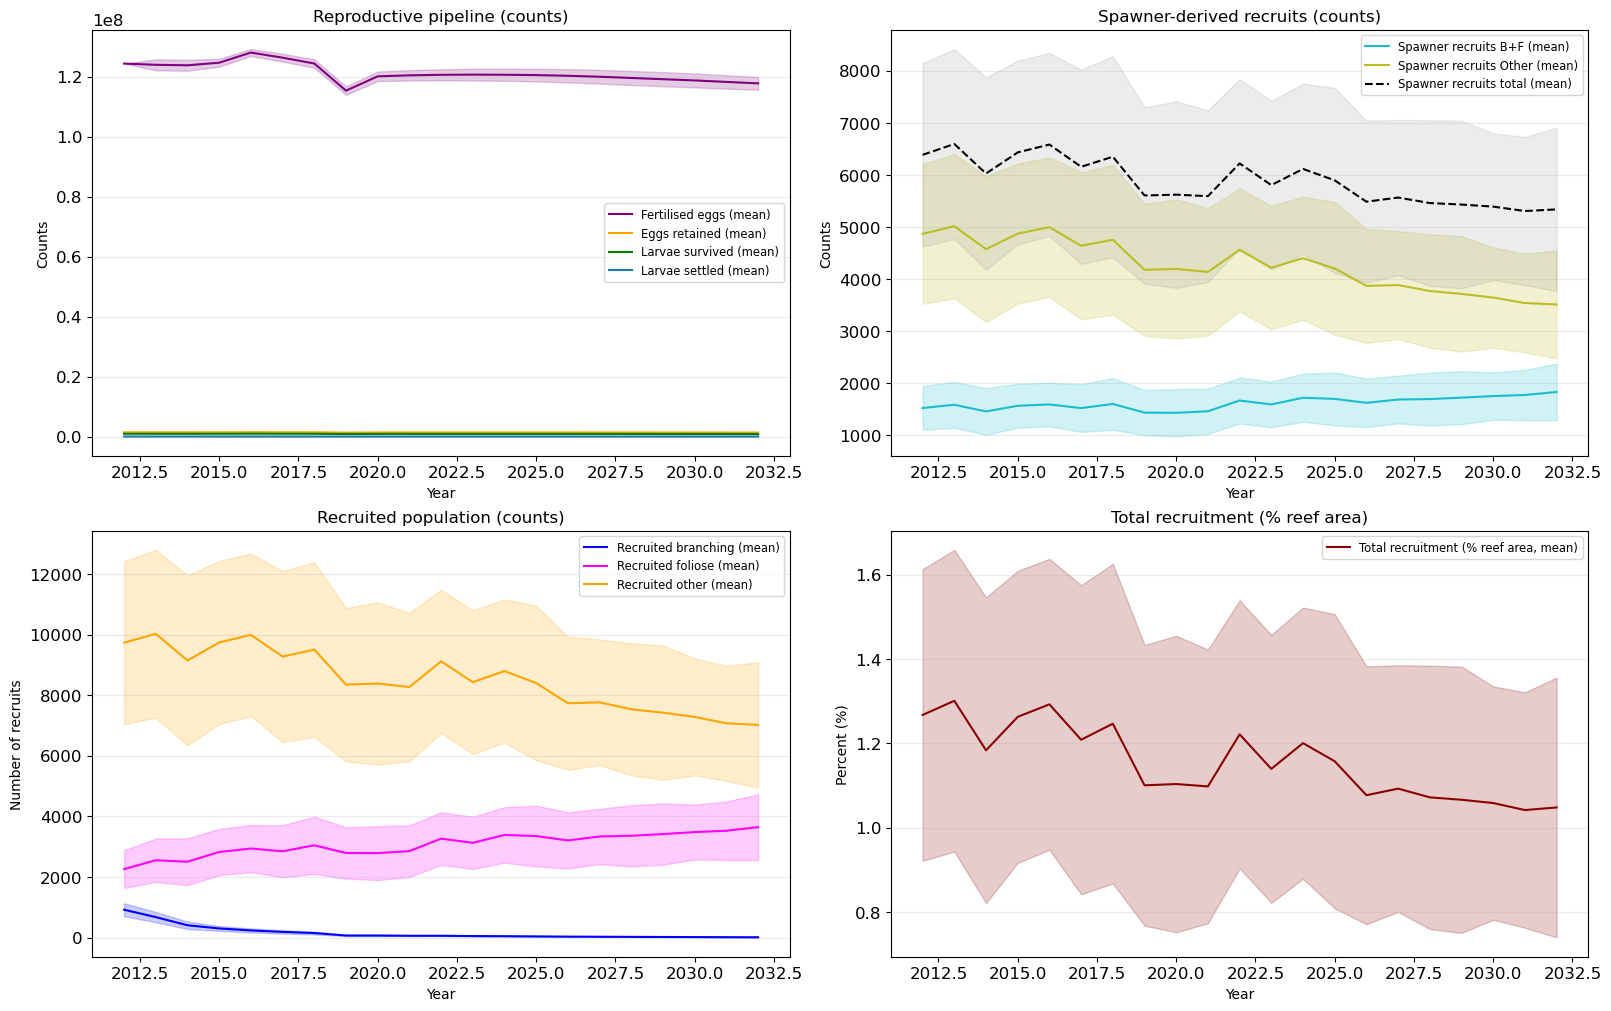

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

# number of iterations from user_inputs.py
n_iter = int(globals().get('number_of_iterations', 100))

# year vector (actual calendar years)
ys = np.arange(int(year_start), int(year_end) + 1)
T = len(ys)  # number of years (MaxYear+1)

# place to store per-iteration time series (each is shape (T,))
metrics = {
    'fertilised_eggs_total': [],
    'eggs_retained_total': [],
    'larvae_survived_total': [],
    'larvae_settled_total': [],
    'num_recruits_spawner_bf': [],
    'num_recruits_spawner_ot': [],
    'num_recruits_spawner_total': [],
    'recruited_branching_pop': [],
    'recruited_foliose_pop': [],
    'recruited_other_pop': [],
    'total_recruitment_perc': []
}

# helpers / constants from environment
area_per_recruit_m2 = area_parameter * np.pi * (binSize / 2.0) ** 2 / 10000.0  # area (m2) of a recruit ~ binSize (5cm) circle
larval_surv_bf = globals().get('larval_survival_rate_branching_foliose', 0.84 * 0.87 * 0.93 * 0.94 * 0.95 * 0.96 * 0.965 * 0.97)
larval_surv_o  = globals().get('larval_survival_rate_other', 0.915**4)

# run model repeatedly and compute simple recruitment diagnostics for each year
for it in range(1, n_iter + 1):
    np.random.seed(42 + it)
    random.seed(42 + it)
    # fix spawn-month for reproducibility per run
    set_current_run_id(it)

    # run model (this sets opts.yearly_* lists for this run)
    run_coral_model(PSD_T0, MaxYear)

    # preallocate arrays for this iteration
    fert = np.zeros(T)
    retained = np.zeros(T)
    survived = np.zeros(T)
    settled = np.zeros(T)
    spbf = np.zeros(T)
    spot = np.zeros(T)
    sptot = np.zeros(T)
    rec_b_pop = np.zeros(T)
    rec_f_pop = np.zeros(T)
    rec_o_pop = np.zeros(T)
    rec_perc = np.zeros(T)

    # per-year calculations using saved per-year state
    for yy in range(T):
        # actual model/year index -> model relative year = yy
        model_year = int(yy)
        actual_year = int(year_start) + yy

        # coral cover percentages for this year (from yearly_total_coral_cover_df)
        try:
            row = opts.yearly_total_coral_cover_df.iloc[yy]
            coral_cover = {
                'Branching': float(row['Branching_Area (%)']),
                'Foliose': float(row['Foliose_Area (%)']),
                'Other': float(row['Other_Area (%)'])
            }
        except Exception:
            # fallback to opts.current_coral_cover if table missing
            coral_cover = opts.current_coral_cover.copy()

        # derive brooder / spawner covers for this year's coral cover
        brooder_pct, spawner_bf_pct, spawner_o_pct = get_brooder_spawner_cover(coral_cover)
        # available substrate % for this year (from benthic table if available)
        try:
            avail_pct = float(opts.yearly_benthic_cover_df.loc[yy, 'available_substrate (%)'])
        except Exception:
            avail_pct = float(getattr(opts, 'available_substrate_percentage', 0.0))

        # spawn month for this run (fixed per-run)
       # spawn_month = get_spawn_month_for_run(_current_run_id)
        try:
            spawn_month = get_spawn_month_for_run(it)
        except Exception:
            try:
                spawn_month = get_spawn_month_for_run(None)
            except Exception:
                try:
                    spawn_month = get_spawn_month_current()
                except Exception:
                    spawn_month = int(getattr(opts, 'spawning_month'))

        # find additional suspended sediment in that spawn month (monthly dictionary created in config/utils)
        suspended_in_month = 0.0
        if 'additional_sediment_exposure' in globals():
            suspended_in_month = float(additional_sediment_exposure.get((model_year, spawn_month), (0.0, 0.0))[0])

        # spawner pool areas (m2) for this year (derived from percent cover)
        reef_m2 = float(opts.reef_area)
        spawner_cover_m2 = [max(0.0, spawner_bf_pct * reef_m2 / 100.0),
                            max(0.0, spawner_o_pct * reef_m2 / 100.0)]

        # eggs produced by each spawner pool (pre-fertilisation)
        eggs_decl = float(eggs_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0))
        eggs_density = getattr(opts, 'eggs_density', [egg_density_spawner_branching_foliose, egg_density_spawner_other])
        number_of_eggs = [10000.0 * eggs_decl * (eggs_density[i] if i < len(eggs_density) else eggs_density[-1]) * spawner_cover_m2[i]
                          for i in range(len(spawner_cover_m2))]

        # apply spawning fraction and colony-level decline
        eggs_spawning_rate = getattr(opts, 'eggs_spawning_rate', [1.0] * len(number_of_eggs))
        colony_decl = colonies_spawning_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0)
        num_eggs_spawning = [number_of_eggs[i] * (eggs_spawning_rate[i] if i < len(eggs_spawning_rate) else eggs_spawning_rate[-1]) * colony_decl
                             for i in range(len(number_of_eggs))]

        # fertilisation rate adjusted by suspended sediment at spawn month
        eggs_fert_rate = float(getattr(opts, 'eggs_fertilisation_rate', np.random.uniform(0.41, 0.69)))
        if suspended_in_month > 0 and getattr(opts, 'enable_sediment_exposure', True):
            coeff = globals().get('sedi_exp_fertilisation_coeff', {}).get('spawner', 0.0)
            susc = float(globals().get('sediment_susceptibilityF', 1.0))
            raw = max(-1.0, min(0.0, coeff * suspended_in_month))
            effective = max(-1.0, min(0.0, raw * susc))
            factor = max(0.0, min(1.0, 1.0 + effective))
            eggs_fert_rate *= factor

        # fertilised eggs (per pool) and totals
        fert_by_pool = [eggs_fert_rate * e for e in num_eggs_spawning]
        fertilised_total = float(np.sum(fert_by_pool))

        # retention (apply retention rates per reef shape)
        ret_bf, ret_o = get_retention_rate()
        eggs_retained_by_pool = [fert_by_pool[0] * ret_bf, fert_by_pool[1] * ret_o]
        eggs_retained_total = float(np.sum(eggs_retained_by_pool))

        # larvae survived (apply larval survival constants)
        larvae_survived_by_pool = [eggs_retained_by_pool[0] * larval_surv_bf, eggs_retained_by_pool[1] * larval_surv_o]
        larvae_surv_total = float(np.sum(larvae_survived_by_pool))

        # settlement (get settlement rate from available substrate)
        settlement_coeff = get_settlement_rate(avail_pct)
        larvae_settled_by_pool = [settlement_coeff * larvae_survived_by_pool[0], settlement_coeff * larvae_survived_by_pool[1]]
        larvae_settled_total = float(np.sum(larvae_settled_by_pool))

        # apply post-settlement early survival / pool-specific survival multipliers (use config rates)
        sp_surv_bf = np.prod(spawner_branching_survival_rates) if 'spawner_branching_survival_rates' in globals() else np.prod([0.81, 0.93, 0.88, 0.9])
        sp_surv_o  = np.prod(spawner_other_survival_rates) if 'spawner_other_survival_rates' in globals() else np.prod([0.865, 0.83, 0.91, 0.925])
        num_recruits_bf = larvae_settled_by_pool[0] * sp_surv_bf
        num_recruits_ot = larvae_settled_by_pool[1] * sp_surv_o
        num_recruits_total_spawner = float(num_recruits_bf + num_recruits_ot)

        # recruited surface area from spawners (m2)
        surface_spawner_bf_m2 = num_recruits_bf * area_per_recruit_m2
        surface_spawner_ot_m2 = num_recruits_ot * area_per_recruit_m2

        # brooder recruits: reproduce simplified version of utils' brooder calculation
        # brooder percent and colony decline applied
        brooder_decl = colonies_spawning_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0)
        brooder_cover_m2 = max(0.0, brooder_pct * reef_m2 / 100.0) * brooder_decl
        # convert brooder cover (m2) to cm2 per m2 proxy used in utils
        brooder_cover_cm2_per_m2 = brooder_cover_m2 * 10000.0 / max(1.0, reef_m2)
        polyp_size = 200 * 1e-4
        number_polyps = brooder_cover_cm2_per_m2 / polyp_size if polyp_size > 0 else 0.0
        number_polyps_per_cm2 = number_polyps / brooder_cover_cm2_per_m2 if brooder_cover_cm2_per_m2 > 0 else 0.0
        number_planulae_released_per_m2 = number_polyps_per_cm2 * 0.05 * brooder_cover_cm2_per_m2 / 25.0
        available_substrate_m2 = avail_pct * reef_m2 / 100.0
        current_total_coral_cover = float(100.0 - getattr(opts, 'unavailable_substrate_percentage', 0.0) - avail_pct)
        growth_param = getattr(opts, 'growth_parameter', 0.5)
        num_recruits_brooder = number_planulae_released_per_m2 * available_substrate_m2 * (1.0 - (current_total_coral_cover / max(1.0, getattr(opts, 'maximum_achievable_substrate_percentage', 100.0))) ** growth_param)
        # apply brooder mortality product
        bro_morts = globals().get('brooder_survival_rates', None)
        if bro_morts is None:
            # utils used mortality rates list and multiplied (1-rate) product
            brooder_mortality_rate = [0.73,0.39,0.37,0.35]
            for r in brooder_mortality_rate:
                num_recruits_brooder *= (1.0 - r)
        else:
            for r in bro_morts:
                num_recruits_brooder *= r

        surface_brooder_m2 = num_recruits_brooder * area_per_recruit_m2

        # combine spawner + brooder recruited surface to produce recruited areas and convert to population counts
        recruited_branching_area_m2 = surface_brooder_m2 + surface_spawner_bf_m2 * (coral_cover['Branching'] / max(1e-12, coral_cover['Branching'] + coral_cover['Foliose']))
        recruited_foliose_area_m2 = surface_spawner_bf_m2 * (coral_cover['Foliose'] / max(1e-12, coral_cover['Branching'] + coral_cover['Foliose']))
        recruited_other_area_m2 = surface_spawner_ot_m2

        # convert recruited areas to population numbers using helper
        rec_b = get_population_number_from_surface_area(0, recruited_branching_area_m2)
        rec_f = get_population_number_from_surface_area(0, recruited_foliose_area_m2)
        rec_o = get_population_number_from_surface_area(0, recruited_other_area_m2)

        total_recruitment_percentage = 100.0 * (surface_brooder_m2 + surface_spawner_bf_m2 + surface_spawner_ot_m2) / max(1.0, reef_m2)

        # store
        fert[yy] = fertilised_total
        retained[yy] = eggs_retained_total
        survived[yy] = larvae_surv_total
        settled[yy] = larvae_settled_total
        spbf[yy] = num_recruits_bf
        spot[yy] = num_recruits_ot
        sptot[yy] = num_recruits_total_spawner
        rec_b_pop[yy] = rec_b
        rec_f_pop[yy] = rec_f
        rec_o_pop[yy] = rec_o
        rec_perc[yy] = total_recruitment_percentage

    # append iteration arrays to metrics
    metrics['fertilised_eggs_total'].append(fert)
    metrics['eggs_retained_total'].append(retained)
    metrics['larvae_survived_total'].append(survived)
    metrics['larvae_settled_total'].append(settled)
    metrics['num_recruits_spawner_bf'].append(spbf)
    metrics['num_recruits_spawner_ot'].append(spot)
    metrics['num_recruits_spawner_total'].append(sptot)
    metrics['recruited_branching_pop'].append(rec_b_pop)
    metrics['recruited_foliose_pop'].append(rec_f_pop)
    metrics['recruited_other_pop'].append(rec_o_pop)
    metrics['total_recruitment_perc'].append(rec_perc)

# convert lists -> arrays (shape: n_iter x T)
for k in list(metrics.keys()):
    metrics[k] = np.vstack(metrics[k]) if len(metrics[k]) > 0 else np.zeros((0, T))

# compute mean and std across iterations
mu = {k: metrics[k].mean(axis=0) if metrics[k].size else np.zeros(T) for k in metrics}
sd = {k: metrics[k].std(axis=0)  if metrics[k].size else np.zeros(T) for k in metrics}

# plotting: 2x2 panels
os.makedirs(r'output/figures', exist_ok=True)
fig, axs = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# Panel 1: eggs -> fertilised, retained, larvae survived, settled (counts)
ax = axs[0,0]
ax.plot(ys, mu['fertilised_eggs_total'], color='purple', label='Fertilised eggs (mean)')
ax.fill_between(ys, mu['fertilised_eggs_total'] - sd['fertilised_eggs_total'], mu['fertilised_eggs_total'] + sd['fertilised_eggs_total'], color='purple', alpha=0.2)
ax.plot(ys, mu['eggs_retained_total'], color='orange', label='Eggs retained (mean)')
ax.fill_between(ys, mu['eggs_retained_total'] - sd['eggs_retained_total'], mu['eggs_retained_total'] + sd['eggs_retained_total'], color='orange', alpha=0.2)
ax.plot(ys, mu['larvae_survived_total'], color='green', label='Larvae survived (mean)')
ax.fill_between(ys, mu['larvae_survived_total'] - sd['larvae_survived_total'], mu['larvae_survived_total'] + sd['larvae_survived_total'], color='green', alpha=0.2)
ax.plot(ys, mu['larvae_settled_total'], color='tab:blue', label='Larvae settled (mean)')
ax.fill_between(ys, mu['larvae_settled_total'] - sd['larvae_settled_total'], mu['larvae_settled_total'] + sd['larvae_settled_total'], color='tab:blue', alpha=0.2)
ax.set_title('Reproductive pipeline (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# Panel 2: spawner recruits (bf, ot, total)
ax = axs[0,1]
ax.plot(ys, mu['num_recruits_spawner_bf'], color='tab:cyan', label='Spawner recruits B+F (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_bf'] - sd['num_recruits_spawner_bf'], mu['num_recruits_spawner_bf'] + sd['num_recruits_spawner_bf'], color='tab:cyan', alpha=0.2)
ax.plot(ys, mu['num_recruits_spawner_ot'], color='tab:olive', label='Spawner recruits Other (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_ot'] - sd['num_recruits_spawner_ot'], mu['num_recruits_spawner_ot'] + sd['num_recruits_spawner_ot'], color='tab:olive', alpha=0.2)
ax.plot(ys, mu['num_recruits_spawner_total'], color='k', linestyle='--', label='Spawner recruits total (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_total'] - sd['num_recruits_spawner_total'], mu['num_recruits_spawner_total'] + sd['num_recruits_spawner_total'], color='grey', alpha=0.15)
ax.set_title('Spawner-derived recruits (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# Panel 3: recruited populations (branching, foliose, other)
ax = axs[1,0]
ax.plot(ys, mu['recruited_branching_pop'], color='blue', label='Recruited branching (mean)')
ax.fill_between(ys, mu['recruited_branching_pop'] - sd['recruited_branching_pop'], mu['recruited_branching_pop'] + sd['recruited_branching_pop'], color='blue', alpha=0.2)
ax.plot(ys, mu['recruited_foliose_pop'], color='magenta', label='Recruited foliose (mean)')
ax.fill_between(ys, mu['recruited_foliose_pop'] - sd['recruited_foliose_pop'], mu['recruited_foliose_pop'] + sd['recruited_foliose_pop'], color='magenta', alpha=0.2)
ax.plot(ys, mu['recruited_other_pop'], color='orange', label='Recruited other (mean)')
ax.fill_between(ys, mu['recruited_other_pop'] - sd['recruited_other_pop'], mu['recruited_other_pop'] + sd['recruited_other_pop'], color='orange', alpha=0.2)
ax.set_title('Recruited population (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Number of recruits')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# Panel 4: total recruitment as % reef area
ax = axs[1,1]
ax.plot(ys, mu['total_recruitment_perc'], color='darkred', label='Total recruitment (% reef area, mean)')
ax.fill_between(ys, mu['total_recruitment_perc'] - sd['total_recruitment_perc'], mu['total_recruitment_perc'] + sd['total_recruitment_perc'], color='darkred', alpha=0.2)
ax.set_title('Total recruitment (% reef area)')
ax.set_xlabel('Year'); ax.set_ylabel('Percent (%)')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# save and show
outpath = os.path.join(r'output/figures', f"{globals().get('title','run')}_recruitment_summary_{n_iter}iter.png")
fig.savefig(outpath, dpi=200, bbox_inches='tight')
print("Saved recruitment summary:", outpath)
plt.show()
# --- END: multi-iteration recruitment diagnostics ---

fertilised_eggs_total (first 5 years): [1.24382417e+08 1.23975151e+08 1.23806390e+08 1.24665993e+08
 1.28054382e+08]
eggs_retained_total (first 5 years): [1417959.5517764  1413316.71983035 1411392.8490903  1421192.31897602
 1459819.95043947]
larvae_survived_total (first 5 years): [930185.14573939 926709.13836119 925082.58432222 930978.81067393
 956734.93267083]
larvae_settled_total (first 5 years): [10597.47304592 10945.14532798 10001.93348307 10676.24899774
 10926.58602497]
Saved recruitment summary: output/figures\C2_2 Ge sedi event sp unknown 27112025_recruitment_summary_100iter.png


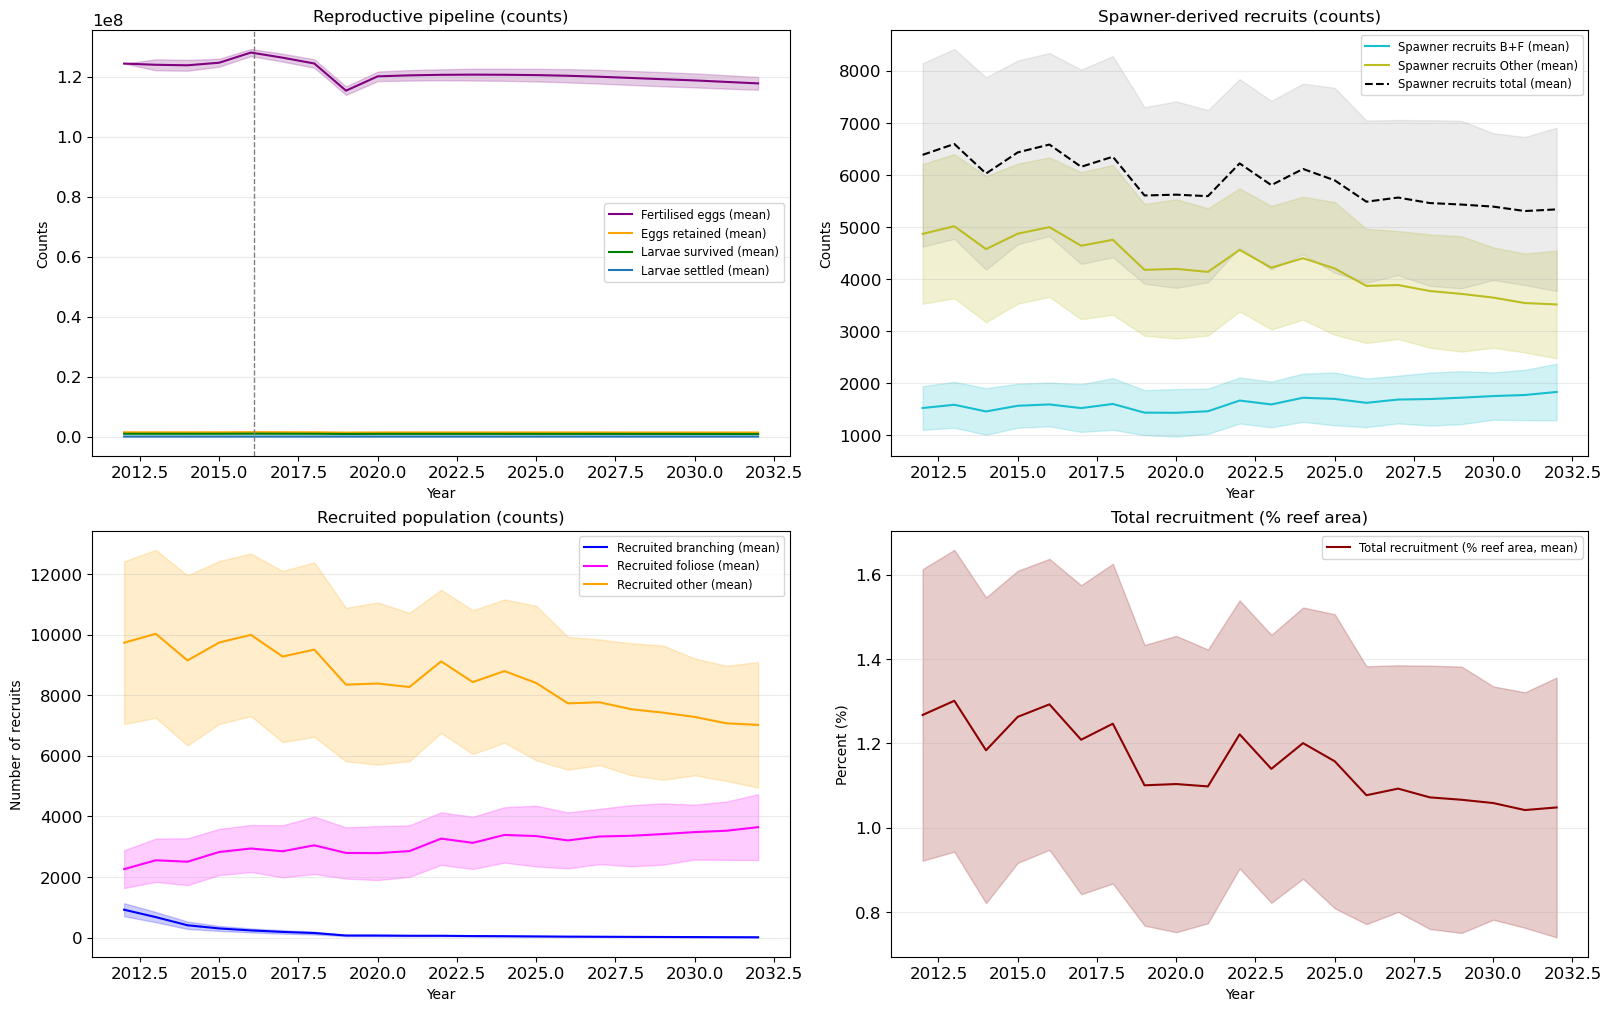

In [14]:
import os

# add vertical dashed line position for event: year 2016, month 2 (February)
# fractional year for plotting on a continuous year axis: 2016 + (month-1)/12
event_vline_x = 2016 + (2 - 1) / 12.0  # 2016.0833333333333
event_vline_kwargs = dict(color='gray', linestyle='--', linewidth=1)

# helper to add the vertical dashed line to an Axes (call after axes are created)
def add_event_vline(ax):
    try:
        ax.axvline(event_vline_x, **event_vline_kwargs)
    except Exception:
        pass
import numpy as np
import matplotlib.pyplot as plt

# number of iterations from user_inputs.py
n_iter = int(globals().get('number_of_iterations', 100))

# year vector (actual calendar years)
ys = np.arange(int(year_start), int(year_end) + 1)
T = len(ys)  # number of years (MaxYear+1)

# place to store per-iteration time series (each is shape (T,))
metrics = {
    'fertilised_eggs_total': [],
    'eggs_retained_total': [],
    'larvae_survived_total': [],
    'larvae_settled_total': [],
    'num_recruits_spawner_bf': [],
    'num_recruits_spawner_ot': [],
    'num_recruits_spawner_total': [],
    'recruited_branching_pop': [],
    'recruited_foliose_pop': [],
    'recruited_other_pop': [],
    'total_recruitment_perc': []
}

# helpers / constants from environment
area_per_recruit_m2 = area_parameter * np.pi * (binSize / 2.0) ** 2 / 10000.0  # area (m2) of a recruit ~ binSize (5cm) circle
larval_surv_bf = globals().get('larval_survival_rate_branching_foliose', 0.84 * 0.87 * 0.93 * 0.94 * 0.95 * 0.96 * 0.965 * 0.97)
larval_surv_o  = globals().get('larval_survival_rate_other', 0.915**4)

# run model repeatedly and compute simple recruitment diagnostics for each year
for it in range(1, n_iter + 1):
    np.random.seed(42 + it)
    random.seed(42 + it)
    # fix spawn-month for reproducibility per run
    set_current_run_id(it)

    # run model (this sets opts.yearly_* lists for this run)
    run_coral_model(PSD_T0, MaxYear)

    # preallocate arrays for this iteration
    fert = np.zeros(T)
    retained = np.zeros(T)
    survived = np.zeros(T)
    settled = np.zeros(T)
    spbf = np.zeros(T)
    spot = np.zeros(T)
    sptot = np.zeros(T)
    rec_b_pop = np.zeros(T)
    rec_f_pop = np.zeros(T)
    rec_o_pop = np.zeros(T)
    rec_perc = np.zeros(T)

    # per-year calculations using saved per-year state
    for yy in range(T):
        # actual model/year index -> model relative year = yy
        model_year = int(yy)
        actual_year = int(year_start) + yy

        # coral cover percentages for this year (from yearly_total_coral_cover_df)
        try:
            row = opts.yearly_total_coral_cover_df.iloc[yy]
            coral_cover = {
                'Branching': float(row['Branching_Area (%)']),
                'Foliose': float(row['Foliose_Area (%)']),
                'Other': float(row['Other_Area (%)'])
            }
        except Exception:
            # fallback to opts.current_coral_cover if table missing
            coral_cover = opts.current_coral_cover.copy()

        # derive brooder / spawner covers for this year's coral cover
        brooder_pct, spawner_bf_pct, spawner_o_pct = get_brooder_spawner_cover(coral_cover)
        # available substrate % for this year (from benthic table if available)
        try:
            avail_pct = float(opts.yearly_benthic_cover_df.loc[yy, 'available_substrate (%)'])
        except Exception:
            avail_pct = float(getattr(opts, 'available_substrate_percentage', 0.0))

        # spawn month for this run (fixed per-run)
       # spawn_month = get_spawn_month_for_run(_current_run_id)
        try:
            spawn_month = get_spawn_month_for_run(it)
        except Exception:
            try:
                spawn_month = get_spawn_month_for_run(None)
            except Exception:
                try:
                    spawn_month = get_spawn_month_current()
                except Exception:
                    spawn_month = int(getattr(opts, 'spawning_month'))

        # find additional suspended sediment in that spawn month (monthly dictionary created in config/utils)
        suspended_in_month = 0.0
        if 'additional_sediment_exposure' in globals():
            suspended_in_month = float(additional_sediment_exposure.get((model_year, spawn_month), (0.0, 0.0))[0])

        # spawner pool areas (m2) for this year (derived from percent cover)
        reef_m2 = float(opts.reef_area)
        spawner_cover_m2 = [max(0.0, spawner_bf_pct * reef_m2 / 100.0),
                            max(0.0, spawner_o_pct * reef_m2 / 100.0)]

        # eggs produced by each spawner pool (pre-fertilisation)
        eggs_decl = float(eggs_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0))
        eggs_density = getattr(opts, 'eggs_density', [egg_density_spawner_branching_foliose, egg_density_spawner_other])
        number_of_eggs = [10000.0 * eggs_decl * (eggs_density[i] if i < len(eggs_density) else eggs_density[-1]) * spawner_cover_m2[i]
                          for i in range(len(spawner_cover_m2))]

        # apply spawning fraction and colony-level decline
        eggs_spawning_rate = getattr(opts, 'eggs_spawning_rate', [1.0] * len(number_of_eggs))
        colony_decl = colonies_spawning_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0)
        num_eggs_spawning = [number_of_eggs[i] * (eggs_spawning_rate[i] if i < len(eggs_spawning_rate) else eggs_spawning_rate[-1]) * colony_decl
                             for i in range(len(number_of_eggs))]

        # fertilisation rate adjusted by suspended sediment at spawn month
        eggs_fert_rate = float(getattr(opts, 'eggs_fertilisation_rate', np.random.uniform(0.41, 0.69)))
        if suspended_in_month > 0 and getattr(opts, 'enable_sediment_exposure', True):
            coeff = globals().get('sedi_exp_fertilisation_coeff', {}).get('spawner', 0.0)
            susc = float(globals().get('sediment_susceptibilityF', 1.0))
            raw = max(-1.0, min(0.0, coeff * suspended_in_month))
            effective = max(-1.0, min(0.0, raw * susc))
            factor = max(0.0, min(1.0, 1.0 + effective))
            eggs_fert_rate *= factor

        # fertilised eggs (per pool) and totals
        fert_by_pool = [eggs_fert_rate * e for e in num_eggs_spawning]
        fertilised_total = float(np.sum(fert_by_pool))

        # retention (apply retention rates per reef shape)
        ret_bf, ret_o = get_retention_rate()
        eggs_retained_by_pool = [fert_by_pool[0] * ret_bf, fert_by_pool[1] * ret_o]
        eggs_retained_total = float(np.sum(eggs_retained_by_pool))

        # larvae survived (apply larval survival constants)
        larvae_survived_by_pool = [eggs_retained_by_pool[0] * larval_surv_bf, eggs_retained_by_pool[1] * larval_surv_o]
        larvae_surv_total = float(np.sum(larvae_survived_by_pool))

        # settlement (get settlement rate from available substrate)
        settlement_coeff = get_settlement_rate(avail_pct)
        larvae_settled_by_pool = [settlement_coeff * larvae_survived_by_pool[0], settlement_coeff * larvae_survived_by_pool[1]]
        larvae_settled_total = float(np.sum(larvae_settled_by_pool))

        # apply post-settlement early survival / pool-specific survival multipliers (use config rates)
        sp_surv_bf = np.prod(spawner_branching_survival_rates) if 'spawner_branching_survival_rates' in globals() else np.prod([0.81, 0.93, 0.88, 0.9])
        sp_surv_o  = np.prod(spawner_other_survival_rates) if 'spawner_other_survival_rates' in globals() else np.prod([0.865, 0.83, 0.91, 0.925])
        num_recruits_bf = larvae_settled_by_pool[0] * sp_surv_bf
        num_recruits_ot = larvae_settled_by_pool[1] * sp_surv_o
        num_recruits_total_spawner = float(num_recruits_bf + num_recruits_ot)

        # recruited surface area from spawners (m2)
        surface_spawner_bf_m2 = num_recruits_bf * area_per_recruit_m2
        surface_spawner_ot_m2 = num_recruits_ot * area_per_recruit_m2

        # brooder recruits: reproduce simplified version of utils' brooder calculation
        # brooder percent and colony decline applied
        brooder_decl = colonies_spawning_decline_rate(getattr(opts, 'dhw_lst', [0])[model_year] if getattr(opts, 'dhw_lst', None) is not None else 0)
        brooder_cover_m2 = max(0.0, brooder_pct * reef_m2 / 100.0) * brooder_decl
        # convert brooder cover (m2) to cm2 per m2 proxy used in utils
        brooder_cover_cm2_per_m2 = brooder_cover_m2 * 10000.0 / max(1.0, reef_m2)
        polyp_size = 200 * 1e-4
        number_polyps = brooder_cover_cm2_per_m2 / polyp_size if polyp_size > 0 else 0.0
        number_polyps_per_cm2 = number_polyps / brooder_cover_cm2_per_m2 if brooder_cover_cm2_per_m2 > 0 else 0.0
        number_planulae_released_per_m2 = number_polyps_per_cm2 * 0.05 * brooder_cover_cm2_per_m2 / 25.0
        available_substrate_m2 = avail_pct * reef_m2 / 100.0
        current_total_coral_cover = float(100.0 - getattr(opts, 'unavailable_substrate_percentage', 0.0) - avail_pct)
        growth_param = getattr(opts, 'growth_parameter', 0.5)
        num_recruits_brooder = number_planulae_released_per_m2 * available_substrate_m2 * (1.0 - (current_total_coral_cover / max(1.0, getattr(opts, 'maximum_achievable_substrate_percentage', 100.0))) ** growth_param)
        # apply brooder mortality product
        bro_morts = globals().get('brooder_survival_rates', None)
        if bro_morts is None:
            # utils used mortality rates list and multiplied (1-rate) product
            brooder_mortality_rate = [0.73,0.39,0.37,0.35]
            for r in brooder_mortality_rate:
                num_recruits_brooder *= (1.0 - r)
        else:
            for r in bro_morts:
                num_recruits_brooder *= r

        surface_brooder_m2 = num_recruits_brooder * area_per_recruit_m2

        # combine spawner + brooder recruited surface to produce recruited areas and convert to population counts
        recruited_branching_area_m2 = surface_brooder_m2 + surface_spawner_bf_m2 * (coral_cover['Branching'] / max(1e-12, coral_cover['Branching'] + coral_cover['Foliose']))
        recruited_foliose_area_m2 = surface_spawner_bf_m2 * (coral_cover['Foliose'] / max(1e-12, coral_cover['Branching'] + coral_cover['Foliose']))
        recruited_other_area_m2 = surface_spawner_ot_m2

        # convert recruited areas to population numbers using helper
        rec_b = get_population_number_from_surface_area(0, recruited_branching_area_m2)
        rec_f = get_population_number_from_surface_area(0, recruited_foliose_area_m2)
        rec_o = get_population_number_from_surface_area(0, recruited_other_area_m2)

        total_recruitment_percentage = 100.0 * (surface_brooder_m2 + surface_spawner_bf_m2 + surface_spawner_ot_m2) / max(1.0, reef_m2)

        # store
        fert[yy] = fertilised_total
        retained[yy] = eggs_retained_total
        survived[yy] = larvae_surv_total
        settled[yy] = larvae_settled_total
        spbf[yy] = num_recruits_bf
        spot[yy] = num_recruits_ot
        sptot[yy] = num_recruits_total_spawner
        rec_b_pop[yy] = rec_b
        rec_f_pop[yy] = rec_f
        rec_o_pop[yy] = rec_o
        rec_perc[yy] = total_recruitment_percentage

    # append iteration arrays to metrics
    metrics['fertilised_eggs_total'].append(fert)
    metrics['eggs_retained_total'].append(retained)
    metrics['larvae_survived_total'].append(survived)
    metrics['larvae_settled_total'].append(settled)
    metrics['num_recruits_spawner_bf'].append(spbf)
    metrics['num_recruits_spawner_ot'].append(spot)
    metrics['num_recruits_spawner_total'].append(sptot)
    metrics['recruited_branching_pop'].append(rec_b_pop)
    metrics['recruited_foliose_pop'].append(rec_f_pop)
    metrics['recruited_other_pop'].append(rec_o_pop)
    metrics['total_recruitment_perc'].append(rec_perc)

# convert lists -> arrays (shape: n_iter x T)
for k in list(metrics.keys()):
    metrics[k] = np.vstack(metrics[k]) if len(metrics[k]) > 0 else np.zeros((0, T))

# compute mean and std across iterations
mu = {k: metrics[k].mean(axis=0) if metrics[k].size else np.zeros(T) for k in metrics}
sd = {k: metrics[k].std(axis=0)  if metrics[k].size else np.zeros(T) for k in metrics}

# plotting: 2x2 panels
os.makedirs(r'output/figures', exist_ok=True)
fig, axs = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

# Panel 1: eggs -> fertilised, retained, larvae survived, settled (counts)
# Sanity-check metrics are per-year and finite
for k in ['fertilised_eggs_total', 'eggs_retained_total', 'larvae_survived_total', 'larvae_settled_total']:
    if k not in mu:
        print(f"Missing metric: {k}")
    else:
        arr = np.asarray(mu[k])
        if arr.size != T:
            print(f"Metric {k} length {arr.size} != T ({T})")
        if not np.all(np.isfinite(arr)):
            print(f"Metric {k} contains non-finite values")
        # show first few years to confirm per-year values
        print(f"{k} (first 5 years):", arr[:min(5, arr.size)])

ax = axs[0,0]
ax.plot(ys, mu['fertilised_eggs_total'], color='purple', label='Fertilised eggs (mean)')
ax.fill_between(ys,
                mu['fertilised_eggs_total'] - sd['fertilised_eggs_total'],
                mu['fertilised_eggs_total'] + sd['fertilised_eggs_total'],
                color='purple', alpha=0.2)
ax.plot(ys, mu['eggs_retained_total'], color='orange', label='Eggs retained (mean)')
ax.fill_between(ys,
                mu['eggs_retained_total'] - sd['eggs_retained_total'],
                mu['eggs_retained_total'] + sd['eggs_retained_total'],
                color='orange', alpha=0.2)
ax.plot(ys, mu['larvae_survived_total'], color='green', label='Larvae survived (mean)')
ax.fill_between(ys,
                mu['larvae_survived_total'] - sd['larvae_survived_total'],
                mu['larvae_survived_total'] + sd['larvae_survived_total'],
                color='green', alpha=0.2)
ax.plot(ys, mu['larvae_settled_total'], color='tab:blue', label='Larvae settled (mean)')
ax.fill_between(ys,
                mu['larvae_settled_total'] - sd['larvae_settled_total'],
                mu['larvae_settled_total'] + sd['larvae_settled_total'],
                color='tab:blue', alpha=0.2)
ax.set_title('Reproductive pipeline (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# draw configured event vertical line for reference
try:
    add_event_vline(ax)
except Exception:
    pass

# Panel 2: spawner recruits (bf, ot, total)
ax = axs[0,1]
ax.plot(ys, mu['num_recruits_spawner_bf'], color='tab:cyan', label='Spawner recruits B+F (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_bf'] - sd['num_recruits_spawner_bf'], mu['num_recruits_spawner_bf'] + sd['num_recruits_spawner_bf'], color='tab:cyan', alpha=0.2)
ax.plot(ys, mu['num_recruits_spawner_ot'], color='tab:olive', label='Spawner recruits Other (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_ot'] - sd['num_recruits_spawner_ot'], mu['num_recruits_spawner_ot'] + sd['num_recruits_spawner_ot'], color='tab:olive', alpha=0.2)
ax.plot(ys, mu['num_recruits_spawner_total'], color='k', linestyle='--', label='Spawner recruits total (mean)')
ax.fill_between(ys, mu['num_recruits_spawner_total'] - sd['num_recruits_spawner_total'], mu['num_recruits_spawner_total'] + sd['num_recruits_spawner_total'], color='grey', alpha=0.15)
ax.set_title('Spawner-derived recruits (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Counts')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# Panel 3: recruited populations (branching, foliose, other)
ax = axs[1,0]
ax.plot(ys, mu['recruited_branching_pop'], color='blue', label='Recruited branching (mean)')
ax.fill_between(ys, mu['recruited_branching_pop'] - sd['recruited_branching_pop'], mu['recruited_branching_pop'] + sd['recruited_branching_pop'], color='blue', alpha=0.2)
ax.plot(ys, mu['recruited_foliose_pop'], color='magenta', label='Recruited foliose (mean)')
ax.fill_between(ys, mu['recruited_foliose_pop'] - sd['recruited_foliose_pop'], mu['recruited_foliose_pop'] + sd['recruited_foliose_pop'], color='magenta', alpha=0.2)
ax.plot(ys, mu['recruited_other_pop'], color='orange', label='Recruited other (mean)')
ax.fill_between(ys, mu['recruited_other_pop'] - sd['recruited_other_pop'], mu['recruited_other_pop'] + sd['recruited_other_pop'], color='orange', alpha=0.2)
ax.set_title('Recruited population (counts)')
ax.set_xlabel('Year'); ax.set_ylabel('Number of recruits')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# Panel 4: total recruitment as % reef area
ax = axs[1,1]
ax.plot(ys, mu['total_recruitment_perc'], color='darkred', label='Total recruitment (% reef area, mean)')
ax.fill_between(ys, mu['total_recruitment_perc'] - sd['total_recruitment_perc'], mu['total_recruitment_perc'] + sd['total_recruitment_perc'], color='darkred', alpha=0.2)
ax.set_title('Total recruitment (% reef area)')
ax.set_xlabel('Year'); ax.set_ylabel('Percent (%)')
ax.legend(fontsize='small'); ax.grid(axis='y', alpha=0.25)

# save and show
outpath = os.path.join(r'output/figures', f"{globals().get('title','run')}_recruitment_summary_{n_iter}iter.png")
fig.savefig(outpath, dpi=200, bbox_inches='tight')
print("Saved recruitment summary:", outpath)
plt.show()
# --- END: multi-iteration recruitment diagnostics ---

Saved: output/figures\C2_2 Ge sedi event sp unknown 27112025_eggs_retained_by_year.png


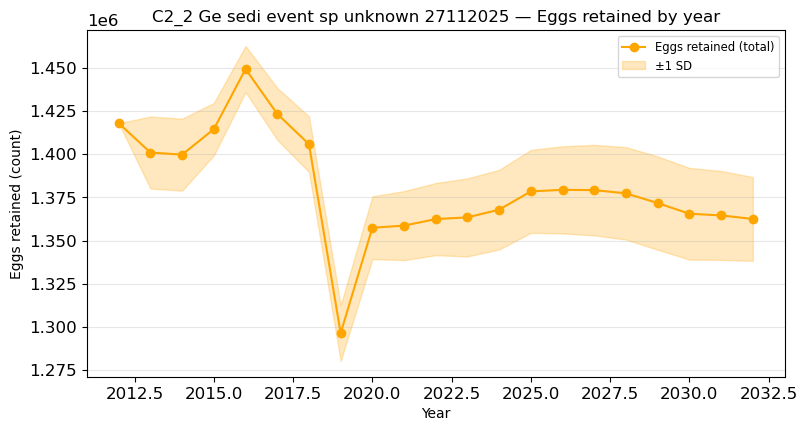

In [15]:
import os

# Plot eggs retained (total) vs year with ±1 SD shading
graph_dir = globals().get('graph_dir', r'output/figures')
os.makedirs(graph_dir, exist_ok=True)

# Resolve years and data from notebook globals (avoid truth-testing numpy arrays)
_years_glob = globals().get('years_actual', None)
if _years_glob is None:
    # safe conversion of start/end
    try:
        start_i = int(globals().get('year_start'))
        end_i = int(globals().get('year_end'))
        years = np.arange(start_i, end_i + 1)
    except Exception:
        years = np.array([], dtype=int)
else:
    years = np.asarray(_years_glob)
    # make sure years is 1-D integer array
    try:
        years = years.astype(int).ravel()
    except Exception:
        years = np.asarray(_years_glob).ravel()

retained_arr = np.asarray(globals().get('retained', np.array([])), dtype=float)

# Try to get precomputed std; fallback to sqrt heuristic if missing
sd_dict = globals().get('sd', {})
sd_arr = None
if isinstance(sd_dict, dict):
    sd_arr = sd_dict.get('eggs_retained_total', None)

if sd_arr is None:
    if retained_arr.size:
        sd_arr = np.sqrt(np.maximum(0.0, retained_arr))
    else:
        sd_arr = np.array([])

sd_arr = np.asarray(sd_arr, dtype=float) if sd_arr is not None else np.array([])

# If years is empty but we have retained data, create a year index for plotting
if years.size == 0 and retained_arr.size:
    years = np.arange(retained_arr.size)

# Ensure arrays align with years length (trim or pad with nan)
def _align_to_years(arr, years_len):
    arr = np.asarray(arr, dtype=float)
    if arr.size == years_len:
        return arr
    if arr.size > years_len:
        return arr[:years_len]
    return np.concatenate([arr, np.full(years_len - arr.size, np.nan)])

years_len = years.size
if retained_arr.size:
    retained_arr = _align_to_years(retained_arr, years_len)
if sd_arr.size:
    sd_arr = _align_to_years(sd_arr, years_len)

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
if retained_arr.size and years_len:
    ax.plot(years, retained_arr, '-o', color='orange', label='Eggs retained (total)')
    if sd_arr.size:
        lower = retained_arr - sd_arr
        upper = retained_arr + sd_arr
        ax.fill_between(years, lower, upper, color='orange', alpha=0.25, label='±1 SD')
else:
    ax.text(0.5, 0.5, "No retained eggs data available", ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel('Year')
ax.set_ylabel('Eggs retained (count)')
ax.set_title(f"{globals().get('title','run')} — Eggs retained by year")
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize='small')

# Save figure
fname = os.path.join(graph_dir, f"{globals().get('title','run')}_eggs_retained_by_year.png")
fig.savefig(fname, dpi=200, bbox_inches='tight')
print(f"Saved: {fname}")

plt.show()

Saved: output/figures\C2_2 Ge sedi event sp unknown 27112025_eggs_pipeline.png


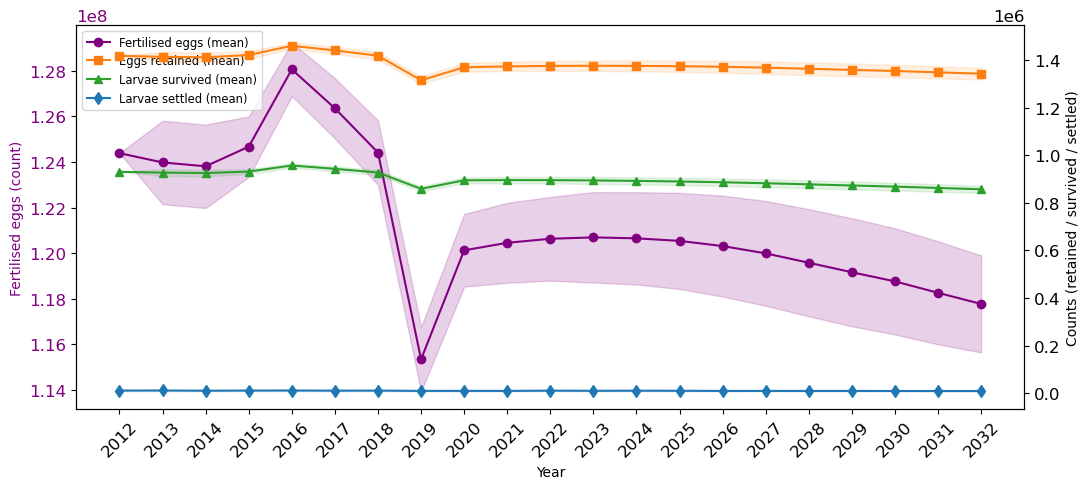

In [16]:
# plot fertilised eggs (primary y) and retained/survived/settled (secondary y) vs actual year
g = globals()

# resolve x (actual years)
x = g.get('years_actual', g.get('years', None))
if x is None:
    try:
        ys = np.arange(int(g.get('year_start')), int(g.get('year_end')) + 1)
        x = ys
    except Exception:
        x = np.array([])

x = np.asarray(x, dtype=float)

# helper to fetch series (prefer mu/mean then fallback to globals)
def get_series(name):
    # try mu dict first (mean across iterations)
    mu = g.get('mu')
    if isinstance(mu, dict) and name in mu:
        return np.asarray(mu[name], dtype=float)
    # try direct global
    if name in g:
        return np.asarray(g[name], dtype=float)
    # common alternate names
    alt = g.get(name + '_series') or g.get(name + '_arr')
    if alt is not None:
        return np.asarray(alt, dtype=float)
    return np.full(x.size, np.nan)

def get_sd(name):
    sd = g.get('sd')
    if isinstance(sd, dict) and name in sd:
        return np.asarray(sd[name], dtype=float)
    # fallback to array named sd_arr if lengths match
    sd_arr = g.get('sd_arr')
    if sd_arr is not None:
        sd_arr = np.asarray(sd_arr, dtype=float)
        if sd_arr.size == x.size:
            return sd_arr
    # fallback heuristic: sqrt for counts
    series = get_series(name)
    if series.size:
        return np.sqrt(np.maximum(0.0, series))
    return np.zeros(x.size)

# series names requested
fert_name = 'fertilised_eggs_total'
ret_name  = 'eggs_retained_total'
surv_name = 'larvae_survived_total'
sett_name = 'larvae_settled_total'

fert = get_series(fert_name)
ret  = get_series(ret_name)
surv = get_series(surv_name)
sett = get_series(sett_name)

sd_fert = get_sd(fert_name)
sd_ret  = get_sd(ret_name)
sd_surv = get_sd(surv_name)
sd_sett = get_sd(sett_name)

# align lengths to x
def align(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == x.size:
        return arr
    if arr.size > x.size:
        return arr[:x.size]
    return np.concatenate([arr, np.full(x.size - arr.size, np.nan)])

fert = align(fert)
ret  = align(ret)
surv = align(surv)
sett = align(sett)
sd_fert = align(sd_fert)
sd_ret  = align(sd_ret)
sd_surv = align(sd_surv)
sd_sett = align(sd_sett)

# plotting
os.makedirs(g.get('graph_dir', 'output/figures'), exist_ok=True)
fig, ax1 = plt.subplots(figsize=(11, 5))

color_f = 'purple'
ax1.plot(x, fert, '-o', color=color_f, label='Fertilised eggs (mean)')
if np.any(np.isfinite(sd_fert)):
    ax1.fill_between(x, fert - sd_fert, fert + sd_fert, color=color_f, alpha=0.18)
ax1.set_xlabel('Year')
ax1.set_ylabel('Fertilised eggs (count)', color=color_f)
ax1.tick_params(axis='y', labelcolor=color_f)
ax1.set_xticks(x)
ax1.set_xticklabels([str(int(y)) for y in x], rotation=45)

ax2 = ax1.twinx()
# colors for secondary series
c_ret, c_surv, c_sett = 'tab:orange', 'tab:green', 'tab:blue'
ax2.plot(x, ret, '-s', color=c_ret, label='Eggs retained (mean)')
ax2.plot(x, surv, '-^', color=c_surv, label='Larvae survived (mean)')
ax2.plot(x, sett, '-d', color=c_sett, label='Larvae settled (mean)')
# shading on secondary
if np.any(np.isfinite(sd_ret)):
    ax2.fill_between(x, ret - sd_ret, ret + sd_ret, color=c_ret, alpha=0.12)
if np.any(np.isfinite(sd_surv)):
    ax2.fill_between(x, surv - sd_surv, surv + sd_surv, color=c_surv, alpha=0.12)
if np.any(np.isfinite(sd_sett)):
    ax2.fill_between(x, sett - sd_sett, sett + sd_sett, color=c_sett, alpha=0.12)

ax2.set_ylabel('Counts (retained / survived / settled)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
handles = h1 + h2
labels = l1 + l2
ax1.legend(handles, labels, loc='upper left', fontsize='small')

title_str = g.get('title', 'run')
outfn = os.path.join(g.get('graph_dir', 'output/figures'), f"{title_str}_eggs_pipeline.png")
fig.tight_layout()
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print("Saved:", outfn)
plt.show()

In [17]:
# import os
# import numpy as np
# import pandas as pd

# # Create CSV of actual year and means for selected metrics

# g = globals()

# # metrics to export (in required order)
# metrics_names = [
#     'fertilised_eggs_total',
#     'eggs_retained_total',
#     'larvae_survived_total',
#     'larvae_settled_total',
#     'num_recruits_spawner_bf',
#     'num_recruits_spawner_ot',
#     'num_recruits_spawner_total',
#     'recruited_branching_pop',
#     'recruited_foliose_pop',
#     'recruited_other_pop',
#     'total_recruitment_perc'
# ]

# # Resolve year index (prefer years_actual, then year_start/year_end)
# years = g.get('years_actual')
# if years is None:
#     try:
#         ys = int(g.get('year_start'))
#         ye = int(g.get('year_end'))
#         years = np.arange(ys, ye + 1)
#     except Exception:
#         years = np.array([], dtype=int)
# years = np.asarray(years, dtype=int)
# n_years = years.size

# def align_to_years(arr):
#     arr = np.asarray(arr, dtype=float)
#     if arr.size == n_years:
#         return arr
#     if arr.size > n_years:
#         return arr[:n_years]
#     return np.concatenate([arr, np.full(n_years - arr.size, np.nan)])

# # Build dictionary of series (means)
# out = {}
# mu = g.get('mu')  # precomputed means across iterations if available
# metrics_obj = g.get('metrics')  # raw metrics dict (may be list-of-arrays or already aggregated)

# for name in metrics_names:
#     series = None
#     # 1) prefer mu dict
#     if isinstance(mu, dict) and name in mu:
#         series = np.asarray(mu[name], dtype=float)
#     # 2) direct global variable with that name
#     elif name in g:
#         series = np.asarray(g[name], dtype=float)
#     # 3) metrics object: if metrics[name] exists and is array (n_iter x T) compute mean
#     elif isinstance(metrics_obj, dict) and name in metrics_obj:
#         val = np.asarray(metrics_obj[name])
#         if val.ndim == 2:
#             # mean across iterations (axis=0)
#             series = val.mean(axis=0)
#         else:
#             series = val
#     # fallback: NaNs
#     if series is None:
#         series = np.full(n_years, np.nan)
#     series = align_to_years(series)
#     out[name] = series

# # Create dataframe and save
# df_out = pd.DataFrame(out, index=years)
# df_out.index.name = 'Year'
# df_out.reset_index(inplace=True)

# # ensure output dir
# out_dir = r'output/tables'
# os.makedirs(out_dir, exist_ok=True)

# # filename using run_id or title
# base = g.get('run_id') or g.get('title') or 'run'
# fname = f"{base}_metrics_means.csv"
# out_path = os.path.join(out_dir, fname)

# df_out.to_csv(out_path, index=False)
# print(f"Saved metrics means CSV to: {out_path}")

# # also expose dataframe to globals for convenience
# globals()['metrics_means_df'] = df_out

Saved: output/figures\C2_2 Ge sedi event sp unknown 27112025_larvae_settled_by_year.png


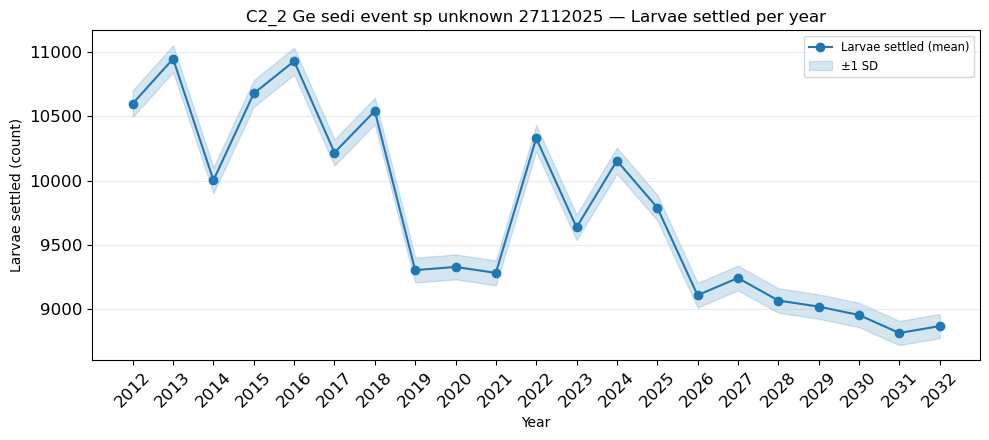

In [18]:
# ...existing code...
# Paste this into a new notebook code cell to plot larvae_settled_total vs year

import os
import numpy as np
import matplotlib.pyplot as plt

g = globals()

# resolve x axis (actual calendar years)
x = g.get('years_actual')
if x is None:
    try:
        ys = int(g.get('year_start'))
        ye = int(g.get('year_end'))
        x = np.arange(ys, ye + 1)
    except Exception:
        x = np.arange(0, (len(g.get('mu', {}).get('larvae_settled_total', [])) or 1))

x = np.asarray(x, dtype=float)

# helper to fetch series (prefer mu dict, then metrics, then direct global name)
def fetch(name):
    mu = g.get('mu')
    if isinstance(mu, dict) and name in mu:
        return np.asarray(mu[name], dtype=float)
    metrics = g.get('metrics')
    if isinstance(metrics, dict) and name in metrics:
        arr = np.asarray(metrics[name])
        if arr.ndim == 2:
            return arr.mean(axis=0)
        return arr
    if name in g:
        return np.asarray(g[name], dtype=float)
    # common alternates
    for alt in (name + '_series', name + '_arr', name.replace('total','')):
        if alt in g:
            try:
                return np.asarray(g[alt], dtype=float)
            except Exception:
                return np.asarray(g[alt])
    return None

y = fetch('larvae_settled_total')
if y is None:
    print("No 'larvae_settled_total' series found (checked mu, metrics and globals).")
else:
    # align y to x length
    def align(arr, n):
        arr = np.asarray(arr, dtype=float)
        if arr.size == n:
            return arr
        if arr.size > n:
            return arr[:n]
        return np.concatenate([arr, np.full(n - arr.size, np.nan)])
    y = align(y, x.size)

    # try to get sd for shading
    sd = None
    sd_dict = g.get('sd')
    if isinstance(sd_dict, dict) and 'larvae_settled_total' in sd_dict:
        sd = np.asarray(sd_dict['larvae_settled_total'], dtype=float)
        sd = align(sd, x.size)
    else:
        # heuristic fallback for count data
        sd = np.sqrt(np.maximum(0.0, np.nan_to_num(y)))

    # plot
    os.makedirs(g.get('graph_dir', 'output/figures'), exist_ok=True)
    fig, ax = plt.subplots(figsize=(10,4.5))
    ax.plot(x, y, '-o', color='tab:blue', label='Larvae settled (mean)')
    if sd is not None:
        ax.fill_between(x, y - sd, y + sd, color='tab:blue', alpha=0.18, label='±1 SD')
    ax.set_xlabel('Year')
    ax.set_ylabel('Larvae settled (count)')
    ax.set_title(f"{g.get('title','run')} — Larvae settled per year")
    ax.grid(axis='y', alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in x], rotation=45)
    ax.legend(fontsize='small')

    outfn = os.path.join(g.get('graph_dir', 'output/figures'), f"{g.get('title','run')}_larvae_settled_by_year.png")
    fig.tight_layout()
    fig.savefig(outfn, dpi=200, bbox_inches='tight')
    print("Saved:", outfn)
    plt.show()
# ...existing code...

Saved: output/figures\C2_2 Ge sedi event sp unknown 27112025_larvae_settled_by_year_with_sd.png


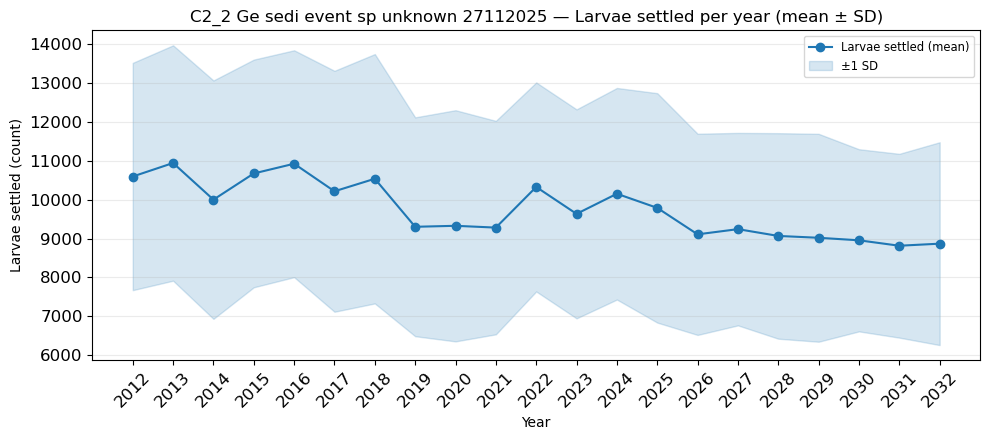

In [19]:
# 

import os
import numpy as np
import matplotlib.pyplot as plt

g = globals()

# resolve x (calendar years)
x = g.get('years_actual')
if x is None:
    try:
        ys = int(g.get('year_start'))
        ye = int(g.get('year_end'))
        x = np.arange(ys, ye + 1)
    except Exception:
        # fallback to length of mu series or metrics
        mu = g.get('mu', {})
        x = np.arange(0, len(mu.get('larvae_settled_total', [])) or 1)
x = np.asarray(x, dtype=float)

# get mean series (prefer mu then metrics then global)
y = None
mu = g.get('mu')
if isinstance(mu, dict) and 'larvae_settled_total' in mu:
    y = np.asarray(mu['larvae_settled_total'], dtype=float)
else:
    metrics = g.get('metrics')
    if isinstance(metrics, dict) and 'larvae_settled_total' in metrics:
        arr = np.asarray(metrics['larvae_settled_total'])
        if arr.ndim == 2:
            y = arr.mean(axis=0)
        else:
            y = arr.astype(float)
    else:
        y = np.asarray(g.get('larvae_settled_total', np.full(x.size, np.nan)), dtype=float)

# compute sd: prefer sd dict then metrics std then heuristic sqrt(counts)
sd = None
sd_dict = g.get('sd')
if isinstance(sd_dict, dict) and 'larvae_settled_total' in sd_dict:
    sd = np.asarray(sd_dict['larvae_settled_total'], dtype=float)
else:
    if isinstance(metrics, dict) and 'larvae_settled_total' in metrics:
        arr = np.asarray(metrics['larvae_settled_total'])
        if arr.ndim == 2:
            sd = arr.std(axis=0)
    if sd is None:
        # heuristic: Poisson-like sqrt for counts, safe nan->0
        sd = np.sqrt(np.maximum(0.0, np.nan_to_num(y)))

# helper: align lengths
def align(arr, n):
    arr = np.asarray(arr, dtype=float)
    if arr.size == n:
        return arr
    if arr.size > n:
        return arr[:n]
    return np.concatenate([arr, np.full(n - arr.size, np.nan)])

y = align(y, x.size)
sd = align(sd, x.size)

# plot
graph_dir = g.get('graph_dir', r'output/figures')
os.makedirs(graph_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x, y, '-o', color='tab:blue', label='Larvae settled (mean)')
lower = np.maximum(0.0, y - sd)   # counts shouldn't go negative
upper = y + sd
ax.fill_between(x, lower, upper, color='tab:blue', alpha=0.18, label='±1 SD')

ax.set_xlabel('Year')
ax.set_ylabel('Larvae settled (count)')
ax.set_title(f"{g.get('title','run')} — Larvae settled per year (mean ± SD)")
ax.grid(axis='y', alpha=0.25)
ax.set_xticks(x)
ax.set_xticklabels([str(int(v)) for v in x], rotation=45)
ax.legend(fontsize='small')

outfn = os.path.join(graph_dir, f"{g.get('title','run')}_larvae_settled_by_year_with_sd.png")
fig.tight_layout()
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print("Saved:", outfn)
plt.show()

In [20]:
# Paste into a new notebook code cell (this replaces the heuristic sd calculation).
import os
import numpy as np
import matplotlib.pyplot as plt

g = globals()

# user-request: compute SD from 100 runs (explicit)
n_runs = 100

# resolve year axis
year_start = int(g.get('year_start'))
year_end = int(g.get('year_end'))
years = np.arange(year_start, year_end + 1)
T = years.size

# if a metrics dict already present (from previous multi-run) prefer that
metrics = g.get('metrics', None)
if isinstance(metrics, dict) and metrics.get('larvae_settled_total') is not None and metrics['larvae_settled_total'].ndim == 2:
    arr = np.asarray(metrics['larvae_settled_total'], dtype=float)
    if arr.shape[0] >= n_runs:
        runs_to_use = arr[:n_runs, :]
    else:
        runs_to_use = arr  # use whatever is available
else:
    # run model n_runs times and collect larvae_settled_total per year
    runs = []
    # helpers / defaults pulled from notebook globals (best-effort)
    area_parameter = float(g.get('area_parameter', 1.0))
    binSize = float(g.get('binSize', 5.0))
    area_per_recruit_m2 = area_parameter * np.pi * (binSize / 2.0) ** 2 / 10000.0
    larval_surv_bf = float(g.get('larval_survival_rate_branching_foliose', 0.84 * 0.87 * 0.93 * 0.94 * 0.95 * 0.96 * 0.965 * 0.97))
    larval_surv_o  = float(g.get('larval_survival_rate_other', 0.915**4))

    # try to re-use helpers present in the notebook
    run_fn = g.get('run_coral_model') or g.get('run_model') or None
    set_run_id = g.get('set_current_run_id', lambda x: None)

    for it in range(1, n_runs + 1):
        np.random.seed(42 + it)
        try:
            set_run_id(it)
        except Exception:
            pass
        # run model (best-effort)
        if callable(run_fn):
            try:
                run_fn(g.get('PSD_T0'), g.get('MaxYear'))
            except Exception:
                try:
                    run_fn()
                except Exception:
                    pass

        # per-year computed quantities (recompute from available globals / opts)
        settled = np.zeros(T, dtype=float)
        try:
            opts = g.get('opts', None)
        except Exception:
            opts = None

        for
        runs.append(settled)

    runs_to_use = np.vstack(runs) if runs else np.zeros((0, T))

# compute mean and sd across runs
if runs_to_use.size == 0:
    mu = np.full(T, np.nan)
    sd = np.full(T, np.nan)
else:
    mu = np.nanmean(runs_to_use, axis=0)
    sd = np.nanstd(runs_to_use, axis=0, ddof=0)

# store into globals for reuse
g['mu'] = g.get('mu', {})
g['sd'] = g.get('sd', {})
g['mu']['larvae_settled_total'] = mu
g['sd']['larvae_settled_total'] = sd

# plotting larvae settled vs year with SD
graph_dir = g.get('graph_dir', r'output/figures')
os.makedirs(graph_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(years, mu, '-o', color='tab:blue', label='Larvae settled (mean)')
lower = np.maximum(0.0, mu - sd)
upper = mu + sd
ax.fill_between(years, lower, upper, color='tab:blue', alpha=0.18, label='±1 SD')

ax.set_xlabel('Year')
ax.set_ylabel('Larvae settled (count)')
ax.set_title(f"{g.get('title','run')} — Larvae settled per year (mean ± SD, n={runs_to_use.shape[0]} runs)")
ax.grid(axis='y', alpha=0.25)
ax.set_xticks(years)
ax.set_xticklabels([str(int(v)) for v in years], rotation=45)
ax.legend(fontsize='small')

outfn = os.path.join(graph_dir, f"{g.get('title','run')}_larvae_settled_by_year_with_sd_{runs_to_use.shape[0]}runs.png")
fig.tight_layout()
fig.savefig(outfn, dpi=200, bbox_inches='tight')
print("Saved:", outfn)
plt.show()

SyntaxError: invalid syntax (901613139.py, line 62)

In [ ]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms